# Image-level Analyzer

Presi i risultati della nostra analisi, si risale al livello delle immagini (quindi le regioni sono raggruppate secondo il loro obs_id) e si cercano pattern e comportamenti interessanti nei risultati.

Le tabelle con i risultati ottenuti da queste analisi sono salvate come csv in "images_results"

In [1]:
import pandas as pd
import numpy as np
import json

In [2]:
predicted_df = pd.read_csv('regions_labels_predicted.csv')
trait_json = open('Lythrum_traits_standardized.json')
traits = json.load(trait_json)

In [3]:
predicted_df.head()

,image_path,cluster_id,leaf,flower,stem,hand,background/undefined,filename,obs_id,group,y_true,y_pred
0,lythrum_virgatum_1111.jpeg_region_2.png,25,1.0,NaN,1.0,NaN,NaN,lythrum_virgatum_1111.jpeg,33281,lythrum_virgatum,0,0
1,lythrum_salicaria_7620.jpg_region_1.png,19,1.0,NaN,1.0,NaN,NaN,lythrum_salicaria_7620.jpg,7619,lythrum_salicaria,0,0
2,lythrum_alatum_5059.jpeg_region_2.png,27,NaN,NaN,NaN,NaN,1.0,lythrum_alatum_5059.jpeg,39768,lythrum_alatum,1,1
3,lythrum_salicaria_4752.jpeg_region_2.png,12,1.0,NaN,1.0,NaN,NaN,lythrum_salicaria_4752.jpeg,4751,lythrum_salicaria,0,1
4,lythrum_alatum_2102.jpeg_region_9.png,25,1.0,NaN,1.0,NaN,NaN,lythrum_alatum_2102.jpeg,36811,lythrum_alatum,1,1


In [4]:
label_columns = ['leaf', 'flower', 'stem', 'hand', 'background/undefined']
info_columns = ['filename', 'obs_id', 'group', 'y_true', 'y_pred']
predicted_df['group'] = predicted_df['group'].str.replace('_', ' ')

def get_characteristic_traits(row, traits_dict):
    species = row['group']  # species
    traits_for_species = traits_dict.get(species, {})
    collected_traits = []
    for label in ['leaf', 'flower', 'stem']:  # only biological traits
        if row[label] == 1:
            label_key = label if label in traits_for_species  else None
            if label_key:
                collected_traits.extend(traits_for_species[label_key])
    return collected_traits

merged_df = predicted_df[info_columns + ['hand', 'background/undefined']].copy()
merged_df['characteristic_traits'] = predicted_df.apply(lambda row: get_characteristic_traits(row, traits), axis=1)
print(merged_df.head())

                      filename  obs_id              group  y_true  y_pred  \
0   lythrum_virgatum_1111.jpeg   33281   lythrum virgatum       0       0   
1   lythrum_salicaria_7620.jpg    7619  lythrum salicaria       0       0   
2     lythrum_alatum_5059.jpeg   39768     lythrum alatum       1       1   
3  lythrum_salicaria_4752.jpeg    4751  lythrum salicaria       0       1   
4     lythrum_alatum_2102.jpeg   36811     lythrum alatum       1       1   

   hand  background/undefined  \
0   NaN                   NaN   
1   NaN                   NaN   
2   NaN                   1.0   
3   NaN                   NaN   
4   NaN                   NaN   

                               characteristic_traits  
0  [leaves opposite, sessile, getting narrower at...  
1  [leaves opposite, sessile, alternate distally,...  
2                                                 []  
3  [leaves opposite, sessile, alternate distally,...  
4  [leaves opposite, becoming alternate distally,...  


In [5]:
merged_df.columns

Index(['filename', 'obs_id', 'group', 'y_true', 'y_pred', 'hand',
       'background/undefined', 'characteristic_traits'],
      dtype='object')

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.formula.api import logit
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from scipy.stats import chi2_contingency, entropy, fisher_exact
from mlxtend.frequent_patterns import apriori, association_rules
from collections import defaultdict


class EnhancedImageLevelAnalyzer:
    """
    Image-level analyzer created from region-level data.
    - Input df must have columns: ['filename','obs_id','group','y_true','y_pred',
      'hand','background/undefined','characteristic_traits']
    - characteristic_traits may be list-like per row or NaN.
    This rewritten class adds:
      - Intro + dynamic interpretation printed for each analysis block.
      - Readable trait co-occurrence (top-N traits).
      - Keeps your original outputs but wraps them with explanations.
    """
    def __init__(self, df):
        print("Preparing data...")
        self.df_regions = df.copy()
        self.df_images = self._aggregate_to_image_level()
        self._prepare_analysis_columns()
        # Ensure integer trait presence columns are filled
        for col in self.trait_cols_present:
            self.df_images[col] = self.df_images[col].fillna(0).astype(int)

        print("Analyzer ready!\n")

    # ----------------- Helpers for printing -----------------
    def _print_header(self, title):
        print("="*60)
        print(title)
        print("="*60)

    def _interpret_ratio(self, a, b, label_a, label_b):
        """simple comparator text for two metrics"""
        if a > b:
            return f"{label_a} ({a:.3f}) > {label_b} ({b:.3f})"
        elif a < b:
            return f"{label_a} ({a:.3f}) < {label_b} ({b:.3f})"
        else:
            return f"{label_a} ({a:.3f}) == {label_b} ({b:.3f})"

    # ---------------- AGGREGATE TO IMAGE LEVEL ----------------
    def _aggregate_to_image_level(self):
        df = self.df_regions.copy()

        def parse_traits(x):
            if isinstance(x, float) and np.isnan(x):
                return []
            if isinstance(x, (list, tuple, np.ndarray)):
                return [str(t).strip() for t in x if (t is not None and str(t).strip()!='')]
            if pd.isna(x):
                return []
            # If string of comma-separated traits, try splitting
            if isinstance(x, str) and (',' in x):
                return [t.strip() for t in x.split(',') if t.strip()!='']
            return [str(x).strip()] if x not in (None, '') else []

        df['traits_list'] = df['characteristic_traits'].apply(parse_traits)

        grouped = []
        for obs_id, g in df.groupby('obs_id'):
            row = {}
            row['obs_id'] = obs_id
            # group/species representative - mode, fallback to first
            try:
                row['group'] = g['group'].mode()[0]
            except:
                row['group'] = g['group'].iloc[0]
            row['n_regions'] = len(g)
            try:
                row['y_true'] = g['y_true'].mode()[0]
            except:
                row['y_true'] = g['y_true'].iloc[0]
            try:
                row['y_pred'] = g['y_pred'].mode()[0]
            except:
                row['y_pred'] = g['y_pred'].iloc[0]
            row['correct_prediction'] = int(row['y_true'] == row['y_pred'])

            if row['y_true'] == row['y_pred']:
                row['error_type'] = 'True Positive' if row['y_true'] == 0 else 'True Negative'
            else:
                row['error_type'] = 'False Positive' if row['y_pred'] == 0 else 'False Negative'

            row['hand_frac'] = g['hand'].fillna(0).mean()
            row['background_frac'] = g['background/undefined'].fillna(0).mean()
            row['hand_count'] = g['hand'].fillna(0).sum()
            row['background_count'] = g['background/undefined'].fillna(0).sum()

            # Traits aggregated across regions
            trait_counts = Counter([t for traits in g['traits_list'] for t in traits])
            total_regions = len(g)
            for trait, count in trait_counts.items():
                safe_trait = str(trait).replace(' ', '_').replace('/','_').replace('-','_')
                row[f'trait_{safe_trait}_present'] = 1
                row[f'trait_{safe_trait}_freq'] = count / total_regions
                row[f'trait_{safe_trait}_count'] = count

            grouped.append(row)

        df_images = pd.DataFrame(grouped).fillna(0)
        # ensure obs_id is first column
        cols = ['obs_id'] + [c for c in df_images.columns if c!='obs_id']
        df_images = df_images[cols]
        print()
        print("In our analysis:")
        print("- True Positive = Invasive plants correctly predicted")
        print("- True Negative = Non Invasive plants correctly predicted")
        print("- False Positive = Non Invasive plants predicted as Invasive")
        print("- False Negative = Invasive plants predicted as Non Invasive")
        print()

        return df_images

    # ---------------- PREPARE ANALYSIS COLUMNS ----------------
    def _prepare_analysis_columns(self):
        # Identify all trait presence/freq/count columns
        self.trait_cols_present = [c for c in self.df_images.columns if c.startswith('trait_') and c.endswith('_present')]
        self.trait_cols_freq = [c for c in self.df_images.columns if c.startswith('trait_') and c.endswith('_freq')]
        self.trait_cols_count = [c for c in self.df_images.columns if c.startswith('trait_') and c.endswith('_count')]

        # Numeric indicators
        self.df_images['error_numeric'] = self.df_images['error_type'].map({
            'True Positive': 0,
            'True Negative': 1,
            'False Positive': 2,
            'False Negative': 3
        }).fillna(0).astype(int)

        # Number of traits per image (presence)
        if len(self.trait_cols_present) > 0:
            self.df_images['num_traits'] = self.df_images[self.trait_cols_present].sum(axis=1)
            self.df_images['trait_diversity'] = self.df_images[self.trait_cols_present].sum(axis=1)
        else:
            self.df_images['num_traits'] = 0
            self.df_images['trait_diversity'] = 0

        # Total occurrences of trait regions in image
        if len(self.trait_cols_count) > 0:
            self.df_images['total_trait_regions'] = self.df_images[self.trait_cols_count].sum(axis=1)
            self.df_images['trait_density'] = np.where(self.df_images['n_regions']>0,
                                                       self.df_images['total_trait_regions'] / self.df_images['n_regions'],
                                                       0)
        else:
            self.df_images['total_trait_regions'] = 0
            self.df_images['trait_density'] = 0

        # Region consensus proxy: if many regions, consensus might dilute (custom heuristic)
        self.df_images['region_consensus'] = np.where(
            self.df_images['n_regions'] == 1, 1.0,
            1.0 - (self.df_images['n_regions'] - 1) * 0.05
        ).clip(0,1)

        self.compute_trait_diversity()
    
    def compute_trait_diversity(self):
        """
        Compute a Shannon diversity index for traits in each image.
        - trait_counts: number of regions per trait
        - diversity = -sum(p_i * log(p_i))
        """
        diversity_list = []
        for _, row in self.df_images.iterrows():
            counts = [row[c] for c in self.trait_cols_count if c in row and row[c]>0]
            if counts:
                freqs = np.array(counts) / np.sum(counts)
                diversity = entropy(freqs)
            else:
                diversity = 0.0
            diversity_list.append(diversity)
        self.df_images['trait_diversity'] = diversity_list
    # ---------------- PERFORMANCE SUMMARY ----------------
    def summary_performance(self):
        self._print_header("IMAGE-LEVEL PERFORMANCE SUMMARY (Intro)")
        print("What you'll see: overall accuracy and counts of different error types at the image level.")
        total = len(self.df_images)
        acc = self.df_images['correct_prediction'].mean() if total>0 else 0
        tp_count = (self.df_images['error_type']=='True Positive').sum()
        tn_count = (self.df_images['error_type']=='True Negative').sum()
        fp_count = (self.df_images['error_type']=='False Positive').sum()
        fn_count = (self.df_images['error_type']=='False Negative').sum()

        precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0.0
        recall = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        print()
        print(f"Overall Accuracy: {acc:.3f} (n={total})")
        print(f"True Positives: {tp_count}")
        print(f"True Negatives: {tn_count}")
        print(f"False Positives: {fp_count}")
        print(f"False Negatives: {fn_count}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall:    {recall:.3f}")
        print(f"F1-Score:  {f1:.3f}")
        print("\nError type counts (table):")
        print(self.df_images['error_type'].value_counts())
        print()

        # Dynamic interpretation
        print("Interpretation:")
        if total == 0:
            print("  No images available for analysis.")
            return acc
        print(f"  - The model's image-level accuracy is {acc:.3f}.")
        compare = self._interpret_ratio(precision, recall, 'Precision', 'Recall')
        print(f"  - {compare}.")
        if precision > recall:
            print("    -> This suggests the model is more conservative: it avoids false positives but may miss true invasive cases.")
        elif recall > precision:
            print("    -> This suggests the model is more sensitive: it catches more true invasive cases but may produce more false alarms.")
        else:
            print("    -> Precision and recall are balanced.")
        if fp_count > fn_count:
            print(f"  - There are more False Positives ({fp_count}) than False Negatives ({fn_count}). Consider checking features that encourage 'invasive' predictions.")
        elif fn_count > fp_count:
            print(f"  - There are more False Negatives ({fn_count}) than False Positives ({fp_count}). The model might be missing invasive plants.")
        else:
            print("  - False Positives and False Negatives are balanced.")
        print()
        return acc

    # ---------------- SPECIES-LEVEL ANALYSIS ----------------
    def species_performance_analysis(self, min_samples=5):
        self._print_header("SPECIES-LEVEL PERFORMANCE ANALYSIS (Intro)")
        print("What you'll see: per-species (group) counts and accuracy. This helps identify species that the model handles poorly or well.")
        species_stats = []
        for species in self.df_images['group'].unique():
            df_species = self.df_images[self.df_images['group'] == species]
            n_images = len(df_species)
            if n_images < 1:
                continue
            stats_row = {
                'species': species,
                'n_images': n_images,
                'accuracy': df_species['correct_prediction'].mean(),
                'tp_rate': (df_species['error_type']=='True Positive').mean(),
                'tn_rate': (df_species['error_type']=='True Negative').mean(),
                'fp_rate': (df_species['error_type']=='False Positive').mean(),
                'fn_rate': (df_species['error_type']=='False Negative').mean(),
                'avg_regions': df_species['n_regions'].mean(),
                'avg_trait_diversity': df_species['trait_diversity'].mean(),
                'invasive_ratio': df_species['y_true'].mean()
            }
            species_stats.append(stats_row)

        species_df = pd.DataFrame(species_stats).sort_values('n_images', ascending=False)
        print()
        if species_df.empty:
            print("No species data available.")
            return species_df

        # Print top/bottom by accuracy with sample size filter
        print("Top species by accuracy (min samples filter):")
        display_df = species_df[species_df['n_images']>=min_samples].sort_values('accuracy', ascending=False)
        print(display_df.head(15))
        print()
        print("Statistical test (ANOVA) to check if accuracies differ across species:")
        # ANOVA - collect only species with >0 samples
        species_accuracies = [self.df_images[self.df_images['group']==sp]['correct_prediction'].values
                              for sp in self.df_images['group'].unique() if len(self.df_images[self.df_images['group']==sp])>0]
        try:
            if len(species_accuracies) > 1:
                f_stat, p_val = stats.f_oneway(*species_accuracies)
                print(f"  ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
                if p_val < 0.05:
                    print("  -> Significant differences in accuracy across species (p < 0.05).")
                else:
                    print("  -> No significant differences in accuracy across species (p >= 0.05).")
            else:
                print("  Not enough species with samples for ANOVA.")
        except Exception as e:
            print("  Could not perform ANOVA:", str(e))

        # Interpretation
        print()
        print("Interpretation:")
        if display_df.empty:
            print("  - After applying the min_samples filter, no species meet the threshold: consider lowering min_samples.")
        else:
            top = display_df.iloc[0]
            bottom = display_df.iloc[-1]
            print(f"  - Best-performing species (sample>= {min_samples}): {top['species']} with accuracy {top['accuracy']:.3f} (n={int(top['n_images'])}).")
            print(f"  - Worst-performing species (sample>= {min_samples}): {bottom['species']} with accuracy {bottom['accuracy']:.3f} (n={int(bottom['n_images'])}).")
            if p_val < 0.05:
                print("  - The ANOVA suggests species-level differences are unlikely to be due to chance. Check species-specific traits or data quality.")
            else:
                print("  - Differences between species are not statistically significant at p<0.05.")
        print()
        return species_df

    # ---------------- TRAIT INTENSITY ANALYSIS ----------------    
    def trait_intensity_analysis(self, min_images=10, stratify=True):
        """
        Analyze how trait intensity (frequency/count) impacts model correctness.
        - Logistic regression for effect size and significance.
        - Quartile comparison: low vs high intensity.
        - Optional stratification by true label (y_true).
        """
        self._print_header("TRAIT INTENSITY ANALYSIS")
        print("This analysis shows whether the amount of a trait in an image affects prediction correctness.\n")

        intensity_results = []
        trait_bases = set([c.replace('trait_','').replace('_present','') for c in self.trait_cols_present])

        for trait_base in trait_bases:
            present_col = f'trait_{trait_base}_present'
            freq_col = f'trait_{trait_base}_freq'
            if present_col not in self.df_images.columns or freq_col not in self.df_images.columns:
                continue

            df_with = self.df_images[self.df_images[present_col]==1]
            if len(df_with) < min_images:
                continue

            # --- Logistic regression ---
            try:
                X = sm.add_constant(df_with[freq_col])
                y = df_with['correct_prediction']
                model = sm.Logit(y, X).fit(disp=0)
                coef = model.params[freq_col]
                pval = model.pvalues[freq_col]
            except:
                coef = np.nan
                pval = np.nan

            # --- Quartile comparison ---
            fq1, fq3 = df_with[freq_col].quantile([0.25, 0.75])
            low_acc = df_with[df_with[freq_col]<=fq1]['correct_prediction'].mean()
            high_acc = df_with[df_with[freq_col]>=fq3]['correct_prediction'].mean()
            effect = high_acc - low_acc

            result = {
                'trait': trait_base,
                'n_images': len(df_with),
                'logit_coef': coef,
                'p_value': pval,
                'low_quartile_acc': low_acc,
                'high_quartile_acc': high_acc,
                'quartile_effect': effect
            }

            # --- Stratification by y_true ---
            if stratify and 'y_true' in self.df_images.columns:
                strat_results = {}
                for cls, df_cls in df_with.groupby('y_true'):
                    fq1_cls, fq3_cls = df_cls[freq_col].quantile([0.25,0.75])
                    low_acc_cls = df_cls[df_cls[freq_col]<=fq1_cls]['correct_prediction'].mean()
                    high_acc_cls = df_cls[df_cls[freq_col]>=fq3_cls]['correct_prediction'].mean()
                    strat_results[cls] = {
                        'low_quartile_acc': low_acc_cls,
                        'high_quartile_acc': high_acc_cls,
                        'quartile_effect': high_acc_cls - low_acc_cls
                    }
                result['stratified'] = strat_results

            intensity_results.append(result)

        intensity_df = pd.DataFrame(intensity_results)
        if intensity_df.empty:
            print("No traits with enough samples for intensity analysis.")
            return intensity_df

        # --- Sort by absolute quartile effect ---
        intensity_df = intensity_df.sort_values('quartile_effect', key=lambda s: s.abs(), ascending=False)

        # --- Output ---
        print("\nTop trait intensity effects (Top 5 traits):\n")
        for _, row in intensity_df.head(5).iterrows():
            trait = row['trait']
            n = row['n_images']
            low_acc = row['low_quartile_acc']
            high_acc = row['high_quartile_acc']
            effect = row['quartile_effect']
            coef = row['logit_coef']
            pval = row['p_value']

            # Direction & significance
            if pd.notna(coef):
                direction = "higher" if coef>0 else "lower"
                sig = "significant" if pval<0.05 else "not significant"
                logit_text = f"(logit_coef={coef:.3f}, {sig}) → {direction} probability of correct prediction"
            else:
                logit_text = "no logit result"

            print(f"Trait '{trait}' (n={n} images):")
            print(f"  - Low frequency (Q1) accuracy = {low_acc:.2f}")
            print(f"  - High frequency (Q3) accuracy = {high_acc:.2f}")
            print(f"  - Quartile effect = {effect:+.3f}")
            print(f"  - Interpretation: {logit_text}")

            if stratify and 'stratified' in row:
                print(f"  - Stratified by true label:")
                for cls, vals in row['stratified'].items():
                    print(f"      {cls}: Low Q1 acc={vals['low_quartile_acc']:.2f}, High Q3 acc={vals['high_quartile_acc']:.2f}, Effect={vals['quartile_effect']:+.3f}")
            print()
        return intensity_df
    
    # ---------------- GLOBAL TRAIT ANALYSIS ----------------
    def global_trait_analysis(self, trait_impact_df=None, trait_intensity_df=None, min_images=10):
        """
        Combine trait presence impact and trait intensity effect into a single table.
        If precomputed tables are provided, use them; otherwise, recompute.
        """
        self._print_header("GLOBAL TRAIT ANALYSIS (Combined)")
        
        if trait_impact_df is None:
            print("Computing trait impact...")
            trait_impact_df = self.trait_impact(min_images=min_images, stratify=True)
        if trait_intensity_df is None:
            print("Computing trait intensity analysis...")
            trait_intensity_df = self.trait_intensity_analysis(min_images=min_images, stratify=True)
        
        # Keep only key columns for merging
        impact_cols = [c for c in ['trait','n_images','impact','p_value','p_value_adj','significant','error_dist','stratified'] if c in trait_impact_df.columns]
        intensity_cols = [c for c in ['trait','quartile_effect','logit_coef','p_value','low_quartile_acc','high_quartile_acc','stratified'] if c in trait_intensity_df.columns]        
        impact_df_clean = trait_impact_df[impact_cols].copy()
        intensity_df_clean = trait_intensity_df[intensity_cols].copy()

        # Rename for clarity
        impact_df_clean = impact_df_clean.rename(columns={
            'n_images':'n_images_impact',
            'impact':'impact',
            'p_value':'p_value_impact',
            'p_value_adj':'p_value_adj_impact',
            'significant':'significant_impact',
            'error_dist':'error_dist_impact',
            'stratified':'stratified_impact'
        })

        intensity_df_clean = intensity_df_clean.rename(columns={
            'quartile_effect':'quartile_effect',
            'logit_coef':'logit_coef',
            'p_value':'p_value_intensity',
            'low_quartile_acc':'low_quartile_acc',
            'high_quartile_acc':'high_quartile_acc',
            'stratified':'stratified_intensity'
        })
        # Merge on trait name
        combined_df = pd.merge(impact_df_clean, intensity_df_clean, on='trait', how='outer')        
        combined_df['impact'] = combined_df['impact'].fillna(np.nan)
        combined_df['significant_impact'] = combined_df['significant_impact'].fillna('No')

        # --- Narrative output ---
        print("\nTop combined trait effects (by absolute presence impact):\n")
        for _, row in combined_df.head(10).iterrows():
            trait = row['trait']
            print(f"Trait '{trait}':")
            # Presence effect
            acc_with = row.get('impact', np.nan)
            if pd.isna(acc_with):
                print(f"Trait '{trait}': insufficient data for presence analysis")
            else:
                sig = row.get('significant_impact', 'No')
                print(f"  - Presence impact = {acc_with:+.3f}, significant={sig}")
            # Intensity effect
            q_effect = row.get('quartile_effect', np.nan)
            logit_coef = row.get('logit_coef', np.nan)
            pval_int = row.get('p_value_intensity', np.nan)
            if pd.notna(q_effect):
                direction = "higher" if logit_coef>0 else "lower"
                sig_text = "significant" if pd.notna(pval_int) and pval_int<0.05 else "not significant"
                print(f"  - Intensity quartile effect = {q_effect:+.3f}, {sig_text}, direction: {direction}")
            # Error tendencies
            if 'error_dist' in row and row['error_dist'] is not None:
                print(f"  - Error type distribution (presence):")
                print(row['error_dist'])
            # Stratified effects
            if 'stratified_impact' in row and row['stratified_impact'] is not None:
                print(f"  - Stratified presence impact:")
                for cls, vals in row['stratified_impact'].items():
                    print(f"      {cls}: effect={vals.get('impact',np.nan):+.3f}")
            if 'stratified_intensity' in row and row['stratified_intensity'] is not None:
                print(f"  - Stratified intensity effect:")
                for cls, vals in row['stratified_intensity'].items():
                    print(f"      {cls}: quartile effect={vals.get('quartile_effect',np.nan):+.3f}")
            print()
        
        return combined_df

    # ---------------- REGION COMPLEXITY ANALYSIS ----------------
    def region_complexity_analysis(self):
        self._print_header("IMAGE COMPLEXITY ANALYSIS (Intro)")
        print("What you'll see: performance by number of extracted regions (image complexity).")
        # Binning regions into categories
        self.df_images['complexity_category'] = pd.cut(
            self.df_images['n_regions'],
            bins=[-1, 1, 3, 5, 10, float('inf')],
            labels=['Simple(1)', 'Low(2-3)', 'Medium(4-5)', 'High(6-10)', 'Very High(10+)']
        )
        complexity_stats = self.df_images.groupby('complexity_category').agg({
            'obs_id': 'count',
            'correct_prediction': 'mean',
            'trait_diversity': 'mean',
            'trait_density': 'mean',
            'hand_frac': 'mean',
            'background_frac': 'mean'
        }).rename(columns={'obs_id':'n_images','correct_prediction':'accuracy'}).round(3)
        print()
        print("Complexity group stats:")
        print(complexity_stats)
        print()
        # ANOVA
        groups = [self.df_images[self.df_images['complexity_category']==cat]['correct_prediction'].values
                  for cat in self.df_images['complexity_category'].dropna().unique()]
        try:
            if len(groups) > 1:
                f_stat, p_val = stats.f_oneway(*groups)
                print(f"ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
            else:
                print("Not enough complexity groups for ANOVA.")
        except Exception as e:
            print("Could not perform ANOVA:", str(e))
        # Interpretation
        print()
        print("Interpretation:")
        if complexity_stats.empty:
            print("  No data for complexity analysis.")
        else:
            best = complexity_stats['accuracy'].idxmax()
            worst = complexity_stats['accuracy'].idxmin()
            print(f"  - Best accuracy in category: {best} ({complexity_stats.loc[best,'accuracy']:.3f})")
            print(f"  - Worst accuracy in category: {worst} ({complexity_stats.loc[worst,'accuracy']:.3f})")
            if 'p_val' in locals() and 'p_val' in locals() and p_val < 0.05:
                print("  - Accuracy differences across complexity categories are statistically significant (p < 0.05).")
            else:
                print("  - No strong statistical evidence that complexity alone drives accuracy differences (p >= 0.05 or not computed).")
        print()
        return complexity_stats
    
        # ---------------- REGION COMPLEXITY ANALYSIS ----------------
    
    # ---------------- TRAIT COMPLEXITY ANALYSIS ----------------
    def trait_complexity_analysis(self):
        """
        Analyze image-level performance based on trait complexity.
        - Uses both number of traits (num_traits) and Shannon diversity (trait_diversity)
        """
        self._print_header("TRAIT COMPLEXITY ANALYSIS (with Shannon diversity)")

        # Ensure trait_diversity is computed
        if 'trait_diversity' not in self.df_images.columns or self.df_images['trait_diversity'].isna().all():
            self.compute_trait_diversity()

        print("Binning images by number of traits (num_traits):")
        self.df_images['num_traits_category'] = pd.cut(
            self.df_images['num_traits'],
            bins=[-1, 1, 3, 5, 10, float('inf')],
            labels=['Very Low(0-1)', 'Low(2-3)', 'Medium(4-5)', 'High(6-10)', 'Very High(10+)']
        )

        print("Binning images by trait diversity (Shannon index):")
        self.df_images['diversity_category'] = pd.qcut(
            self.df_images['trait_diversity'],
            q=5,
            duplicates='drop',
            labels=['Very Low','Low','Medium','High','Very High']
        )

        # Compute stats for both metrics
        def compute_stats(cat_col, label):
            stats_df = self.df_images.groupby(cat_col).agg({
                'obs_id':'count',
                'correct_prediction':'mean',
                'hand_frac':'mean',
                'background_frac':'mean'
            }).rename(columns={'obs_id':'n_images','correct_prediction':'accuracy'}).round(3)
            print(f"\nPerformance by {label}:")
            print(stats_df)

            # ANOVA
            groups = [self.df_images[self.df_images[cat_col]==cat]['correct_prediction'].values
                    for cat in self.df_images[cat_col].dropna().unique()]
            try:
                if len(groups) > 1:
                    f_stat, p_val = stats.f_oneway(*groups)
                    print(f"ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
                else:
                    print("Not enough groups for ANOVA.")
            except Exception as e:
                print("Could not perform ANOVA:", str(e))

            # Interpretation
            if not stats_df.empty:
                best = stats_df['accuracy'].idxmax()
                worst = stats_df['accuracy'].idxmin()
                print(f"  - Best accuracy: {best} ({stats_df.loc[best,'accuracy']:.3f})")
                print(f"  - Worst accuracy: {worst} ({stats_df.loc[worst,'accuracy']:.3f})")
                if 'p_val' in locals() and p_val < 0.05:
                    print("  - Differences across categories are statistically significant (p<0.05).")
                else:
                    print("  - No strong statistical evidence that this metric alone drives accuracy differences (p>=0.05).")
            return stats_df

        stats_num_traits = compute_stats('num_traits_category', 'number of traits')
        stats_diversity = compute_stats('diversity_category', 'trait diversity (Shannon index)')

        return stats_num_traits, stats_diversity

    # ---------------- PREDICTIVE FEATURE IMPORTANCE ----------------
    def predictive_feature_analysis(self, top_n=15):
        """
        Random Forest feature importance for image-level prediction correctness.
        - Includes global analysis and per-error-type (TP, TN, FP, FN) analysis.
        - Features include: trait presence, trait frequency, hand_frac, background_frac, n_regions, trait_diversity, trait_density.
        """
        self._print_header("PREDICTIVE FEATURE IMPORTANCE (Intro)")
        print("What you'll see: Random Forest feature importances predicting whether the image-level prediction was correct.\n")

        # Build feature set
        feature_cols = list(self.trait_cols_present) + list(self.trait_cols_freq)
        # Add aggregate features
        candidate = ['n_regions', 'trait_diversity', 'trait_density', 'hand_frac', 'background_frac']
        for c in candidate:
            if c in self.df_images.columns:
                feature_cols.append(c)

        if len(feature_cols) == 0:
            print("No features available for RF analysis.")
            return pd.DataFrame()

        X = self.df_images[feature_cols].fillna(0)
        y = self.df_images['correct_prediction']

        # ---------- Global Random Forest ----------
        rf_global = RandomForestClassifier(n_estimators=200, random_state=42)
        rf_global.fit(X, y)

        fi_global = pd.DataFrame({'feature': feature_cols, 'importance': rf_global.feature_importances_}).sort_values('importance', ascending=False)
        print("Top global predictive features:")
        print(fi_global.head(top_n))

        # Cross-validation
        try:
            cv_scores = cross_val_score(rf_global, X, y, cv=5)
            print(f"\nGlobal RF CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
        except Exception as e:
            print("Cross-validation failed:", str(e))

        # ---------- Interpretation ----------
        print("\nInterpretation (global):")
        top = fi_global.head(5)
        for _, row in top.iterrows():
            print(f"  - {row['feature']} has importance {row['importance']:.3f}")
        if fi_global['importance'].iloc[0] > 0.2:
            print("  - The top feature is strongly predictive (importance > 0.2). Investigate this feature for potential strong signal or data leakage.")
        else:
            print("  - No single dominant feature; prediction correctness appears distributed across features.")


        # ---------- Feature importances per error type ----------
        error_types = ['True Positive','True Negative','False Positive','False Negative']
        fi_per_error = {}
        for et in error_types:
            df_et = self.df_images[self.df_images['error_type']==et]
            if len(df_et) < 5:
                continue  # skip if too few samples
            X_et = self.df_images[feature_cols].fillna(0)
            y_et = (self.df_images['error_type'] == et).astype(int) #one-vs-all: "is this the the error type or not?"
            if y_et.sum() < 5 or y_et.sum() == 0:
                continue  # too few positives
            rf_et = RandomForestClassifier(n_estimators=200, random_state=42)
            rf_et.fit(X_et, y_et)
            fi_et = pd.DataFrame({'feature': feature_cols, 'importance': rf_et.feature_importances_}).sort_values('importance', ascending=False)
            fi_per_error[et] = fi_et
            print(f"\nTop features for {et}:")
            print(fi_et.head(top_n))

            # ---------- Interpretation ----------
            print("\nInterpretation (global):")
            top_et = fi_et.head(3)
            for _, row in top_et.iterrows():
                print(f"  - {row['feature']} has importance {row['importance']:.3f}")
            if fi_et['importance'].iloc[0] > 0.2:
                print("  - The top feature is strongly predictive (importance > 0.2). Investigate this feature for potential strong signal or data leakage.")
            else:
                print("  - No single dominant feature; prediction correctness appears distributed across features.")



        return fi_global, fi_per_error

    # ---------------- ERROR PATTERN ANALYSIS ----------------
    def error_pattern_analysis(self, top_n_traits=8):
        """
        Enhanced error pattern analysis:
        - Shows typical traits in False Positives and False Negatives
        - Stratified by ground truth (y_true)
        - Includes average number of regions and trait diversity
        - Outputs structured results and readable interpretation
        """
        self._print_header("ERROR PATTERN ANALYSIS (Enhanced)")
        print("What you'll see: top traits in FP/FN images, average image complexity, stratified by true class.\n")

        error_patterns = {}
        error_types = ['False Positive', 'False Negative']

        for et in error_types:
            df_et = self.df_images[self.df_images['error_type'] == et]
            if len(df_et) == 0:
                continue

            pattern_dict = {'total_count': len(df_et), 'by_y_true': {}}
            for y in df_et['y_true'].unique():
                df_sub = df_et[df_et['y_true'] == y]
                n_sub = len(df_sub)
                if n_sub == 0:
                    continue
                # Top traits by fraction
                top_traits = df_sub[self.trait_cols_present].mean().sort_values(ascending=False).head(top_n_traits)
                pattern_dict['by_y_true'][y] = {
                    'count': n_sub,
                    'top_traits': {t.replace('trait_','').replace('_present',''): round(f,3) 
                                for t,f in top_traits.items()},
                    'avg_regions': round(df_sub['n_regions'].mean(),2),
                    'avg_trait_diversity': round(df_sub['trait_diversity'].mean(),3)
                }

            error_patterns[et] = pattern_dict

        # ---------- Output ----------
        if not error_patterns:
            print("No error patterns (no FP or FN found).")
            return error_patterns

        for et, info in error_patterns.items():
            print(f"{et} (total n={info['total_count']})")
            for y_true_val, stats in info['by_y_true'].items():
                print(f"  - y_true = {y_true_val} (n={stats['count']})")
                print(f"    Avg regions: {stats['avg_regions']}, Avg trait diversity: {stats['avg_trait_diversity']}")
                print("    Top traits (fraction of images with trait):")
                for trait, val in stats['top_traits'].items():
                    print(f"      - {trait}: {val:.3f}")
            print()

        # ---------- Interpretation ----------
        print("Interpretation:")
        for et, info in error_patterns.items():
            for y_true_val, stats in info['by_y_true'].items():
                top3_traits = list(stats['top_traits'].keys())[:3]
                if et == 'False Positive':
                    print(f"  - FP images with y_true={y_true_val} (n={stats['count']}) commonly show traits: {', '.join(top3_traits)}")
                    print("    -> These traits may cause over-prediction of invasiveness.")
                else:
                    print(f"  - FN images with y_true={y_true_val} (n={stats['count']}) commonly show traits: {', '.join(top3_traits)}")
                    print("    -> These traits may be associated with missed invasive cases.")
        print()

        return error_patterns


    # ---------------- ANNOTATION LABEL IMPACT ----------------
    def analyze_annotation_labels(self, run_regression=True):
        """
        Analyze whether 'hand' or 'background/undefined' labels correlate with model performance.
        - Reports presence/absence impact on accuracy (with chi² test).
        - Adds correlation with fraction of regions labeled.
        - Shows error type distribution (FP/FN/TP/TN).
        - Optionally runs logistic regression to test predictive power.
        """
        self._print_header("ANNOTATION LABEL IMPACT")
        print("We test whether 'hand' or 'background/undefined' annotations impact model correctness.")
        print("Includes presence/absence comparison, correlation with fractions, error-type breakdown, and regression.\n")

        for col, pretty in [('hand_frac','Hand'), ('background_frac','Background')]:

            print("-"*40)
            print(f"Analysis for label: {pretty}")
            print("-"*40)

            # -------- Presence vs Absence --------
            has_label = self.df_images[col] > 0
            df_with = self.df_images[has_label]
            df_without = self.df_images[~has_label]

            acc_with = df_with['correct_prediction'].mean() if len(df_with)>0 else np.nan
            acc_without = df_without['correct_prediction'].mean() if len(df_without)>0 else np.nan
            diff = acc_with - acc_without if not (np.isnan(acc_with) or np.isnan(acc_without)) else np.nan

            print(f"  With {pretty}:   Acc={acc_with:.3f} (n={len(df_with)})")
            print(f"  Without {pretty}: Acc={acc_without:.3f} (n={len(df_without)})")
            print(f"  Difference: {diff:+.3f}")

            contingency = pd.crosstab(has_label, self.df_images['correct_prediction'])
            if contingency.shape == (2,2):
                chi2, p, _, _ = stats.chi2_contingency(contingency)
                signif = "SIGNIFICANT" if p<0.05 else "NOT significant"
                print(f"  Chi-square test: {signif} (p={p:.4f})")
            else:
                print("  Chi-square test not applicable (imbalanced groups).")

            # -------- Correlation with fraction --------
            corr = self.df_images[[col, 'correct_prediction']].corr().iloc[0,1]
            print(f"  Correlation between {pretty} fraction and accuracy: r={corr:.3f}")

            # -------- Error type stratification --------
            error_dist = pd.crosstab(has_label, self.df_images['error_type'], normalize='index')
            print("  Error type distribution (row-normalized):")
            print(error_dist)

            # -------- Interpretation --------
            if not np.isnan(diff):
                if diff > 0.02:
                    print(f"  Interpretation: Presence of '{pretty}' is associated with slightly higher accuracy (diff={diff:.3f}).")
                elif diff < -0.02:
                    print(f"  Interpretation: Presence of '{pretty}' is associated with slightly lower accuracy (diff={diff:.3f}).")
                else:
                    print(f"  Interpretation: No meaningful difference in accuracy with/without '{pretty}'.")
            print()

        # -------- Logistic regression (optional) --------
        if run_regression:
            try:
                print("-"*60)
                print("LOGISTIC REGRESSION: Predicting correctness from hand/background fractions")
                model = logit("correct_prediction ~ hand_frac + background_frac", data=self.df_images).fit(disp=0)
                print(model.summary())
                # --- Dynamic interpretation ---
                params = model.params
                pvalues = model.pvalues

                print("\nDynamic Interpretation:")
                for var in ['hand_frac', 'background_frac']:
                    coef = params.get(var, None)
                    pval = pvalues.get(var, None)
                    if coef is None or pval is None:
                        continue

                    if pval < 0.05:
                        direction = "higher" if coef > 0 else "lower"
                        print(f"  - {var}: Significant (p={pval:.4f}). More {var} is associated with {direction} probability of a correct prediction.")
                    else:
                        print(f"  - {var}: Not significant (p={pval:.4f}). No strong evidence of impact on correctness.")

                print("\nNote: Coefficients are in log-odds space. A positive coef means increasing the feature increases odds of correctness.")
                print("-"*60 + "\n")
            except Exception as e:
                print("Could not run regression:", e)

        return


    # ---------------- TRAIT IMPACT (per trait presence) ----------------
    def trait_impact(self, min_images=10, adjust_p=True, stratify=True):
        """
        Analyze trait-level impact on model performance.
        - Presence vs absence accuracy and chi² test.
        - Error type breakdown.
        - Multiple test correction (FDR).
        - Optional stratification by class (invasive vs non-invasive).
        """
        self._print_header("TRAIT IMPACT (Expanded, Clean)")
        print("We test whether traits influence model correctness.")
        print("Includes presence/absence comparison, error-type breakdown, multiple-test correction, and optional stratification.\n")

        results = []
        for col in self.trait_cols_present:
            trait_name = col.replace('trait_','').replace('_present','')
            n_images = int(self.df_images[col].sum())
            if n_images < min_images:
                continue

            # --- Presence vs absence ---
            df_with = self.df_images[self.df_images[col]==1]
            df_without = self.df_images[self.df_images[col]==0]
            acc_with = df_with['correct_prediction'].mean() if len(df_with)>0 else np.nan
            acc_without = df_without['correct_prediction'].mean() if len(df_without)>0 else np.nan
            diff = acc_with - acc_without if not (np.isnan(acc_with) or np.isnan(acc_without)) else np.nan

            # --- Chi² test ---
            contingency = pd.crosstab(self.df_images[col], self.df_images['correct_prediction'])
            if contingency.shape == (2,2):
                try:
                    chi2, p, _, _ = stats.chi2_contingency(contingency)
                except:
                    p = 1.0
            else:
                p = 1.0

            # --- Error type breakdown ---
            error_dist = pd.crosstab(self.df_images[col], self.df_images['error_type'], normalize='index')

            res = {
                'trait': trait_name,
                'n_images': n_images,
                'acc_with': acc_with,
                'acc_without': acc_without,
                'impact': diff,
                'p_value': p,
                'error_dist': error_dist
            }

            # --- Stratification by true label (optional) ---
            if stratify and 'y_true' in self.df_images.columns:
                strat_acc = {}
                for cls, df_cls in self.df_images.groupby('y_true'):
                    with_acc = df_cls[df_cls[col]==1]['correct_prediction'].mean()
                    without_acc = df_cls[df_cls[col]==0]['correct_prediction'].mean()
                    strat_acc[cls] = {
                        'with': with_acc,
                        'without': without_acc,
                        'impact': with_acc - without_acc if pd.notna(with_acc) and pd.notna(without_acc) else np.nan
                    }
                res['stratified'] = strat_acc

            results.append(res)

        df_res = pd.DataFrame(results)

        # --- Multiple-test correction ---
        if not df_res.empty and adjust_p:
            reject, pvals_corr, _, _ = multipletests(df_res['p_value'], method='fdr_bh')
            df_res['p_value_adj'] = pvals_corr
            df_res['significant'] = ['Yes' if r else 'No' for r in reject]
        else:
            df_res['p_value_adj'] = df_res['p_value']
            df_res['significant'] = ['Yes' if p<0.05 else 'No' for p in df_res['p_value']]

        # --- Sorting ---
        df_res = df_res.sort_values('impact', key=lambda s: s.abs(), ascending=False)

        if df_res.empty:
            print("No traits meet the min_images threshold for trait impact.")
            return df_res

        print("\nTop trait impacts (by absolute accuracy difference):")
        print(df_res[['trait','n_images','acc_with','acc_without','impact','p_value','p_value_adj','significant']].head(20))

        # --- Interpretation ---
        print("\nInterpretation:")
        top = df_res.iloc[0]
        print(f"  - Trait with largest impact: '{top['trait']}' (n={top['n_images']}), impact={top['impact']:.3f}, significant={top['significant']}")
        sig_count = df_res['significant'].value_counts().get('Yes', 0)
        if sig_count > 0:
            print(f"  - {sig_count} traits remain significant after correction (FDR). These are most reliable candidates.")
        else:
            print("  - No traits are significant after correction (FDR). Effects may be due to chance.")

        # --- Error tendencies (top 5 traits) ---
        print("\nError type tendencies (top 5 traits):")
        for _, row in df_res.head(5).iterrows():
            print(f"  - {row['trait']}:")
            print(row['error_dist'])
            print()

        # --- Stratified results (if available) ---
        if stratify and 'stratified' in df_res.columns:
            print("\nStratified results by true label (example from top 5 traits):")
            for _, row in df_res.head(5).iterrows():
                print(f"  - {row['trait']}:")
                for cls, vals in row['stratified'].items():
                    print(f"      {cls}: acc_with={vals['with']:.3f}, acc_without={vals['without']:.3f}, impact={vals['impact']:.3f}")
                print()

        return df_res

    # ---------------- TRAIT COMBINATION ANALYSIS ----------------
    def trait_rule_analysis_apriori(self, min_support=0.01, min_confidence=0.6, max_len=4):
        """
        Use Apriori to find frequent trait subsets and evaluate their effect on prediction correctness.
        - min_support: minimum fraction of images where rule applies
        - min_confidence: minimum confidence (correct_prediction rate)
        - max_len: max number of traits in a rule
        """
        self._print_header("TRAIT RULE ANALYSIS (Apriori)")
        print(f"Mining frequent trait subsets (support ≥ {min_support}, confidence ≥ {min_confidence}, max_len={max_len}).")
        
        df = self.df_images.copy()
        transactions = df[self.trait_cols_present].astype(int)

        error_types = ['True Positive','True Negative','False Positive','False Negative']
        for etype in error_types:
            transactions[etype] = (df['error_type']==etype).astype(int)

        freq_itemsets = apriori(transactions, min_support=min_support, use_colnames=True)
        rules = association_rules(freq_itemsets, metric="confidence", min_threshold=min_confidence)
        rules = rules[rules['consequents'].apply(lambda x: any(e in x for e in error_types))].copy()

        rules_per_type = defaultdict(pd.DataFrame)
        for etype in error_types:
            df_type = rules[rules['consequents'].apply(lambda x: etype in x)].copy()
            df_type['consequents'] = df_type['consequents'].apply(lambda x: frozenset([etype]))
            df_type = df_type.sort_values(['confidence','lift'], ascending=[False, False]).reset_index(drop=True)
            rules_per_type[etype] = df_type
            df_type = df_type.groupby('antecedents', as_index=False).agg({
                'confidence':'max',
                'lift':'max',
                'support':'max'
            })

            print(f"\nTop rules for {etype}:")
            if not df_type.empty:
                print(df_type[['antecedents','confidence','lift']].head(5))
                print(f"Interpretation: Traits {list(df_type.iloc[0]['antecedents'])} strongly predict {etype}.")
            else:
                print("No strong rules found.")


        return rules_per_type

    # ---------------- TRAIT PREDICTION PATTERN ANALYSIS ----------------
    def trait_prediction_pattern_analysis(self, min_images=50):
        self._print_header("TRAIT PREDICTION PATTERN ANALYSIS (Intro)")
        print("What you'll see: traits that create contrasting effects across TP/TN/FP/FN proportions.")
        records = []
        for col in self.trait_cols_present:
            trait = col.replace('trait_','').replace('_present','')
            n_images = int(self.df_images[col].sum())
            if n_images < min_images:
                continue
            df_with = self.df_images[self.df_images[col]==1]
            df_without = self.df_images[self.df_images[col]==0]
            # fractions:
            def frac(df, kind):
                return (df['error_type']==kind).mean() if len(df)>0 else 0.0
            tp_with = frac(df_with,'True Positive'); tn_with = frac(df_with,'True Negative')
            fp_with = frac(df_with,'False Positive'); fn_with = frac(df_with,'False Negative')
            tp_without = frac(df_without,'True Positive'); tn_without = frac(df_without,'True Negative')
            fp_without = frac(df_without,'False Positive'); fn_without = frac(df_without,'False Negative')
            tp_change = tp_with - tp_without
            tn_change = tn_with - tn_without
            fp_change = fp_with - fp_without
            fn_change = fn_with - fn_without
            asymmetry = abs(tp_change) + abs(tn_change) + abs(fp_change) + abs(fn_change)
            pattern_type = 'polarizing' if tp_change * tn_change < 0 else 'aligned'
            # p-value via chi2 on TP/TN counts
            contingency = pd.DataFrame([
                [ (df_with['error_type']=='True Positive').sum(), (df_without['error_type']=='True Positive').sum() ],
                [ (df_with['error_type']=='True Negative').sum(), (df_without['error_type']=='True Negative').sum() ]
            ])
            try:
                chi2, p, _, _ = stats.chi2_contingency(contingency)
            except:
                p = 1.0
            records.append({
                'trait': trait,
                'n_images': n_images,
                'tp_change': tp_change,
                'tn_change': tn_change,
                'fp_change': fp_change,
                'fn_change': fn_change,
                'asymmetry_score': asymmetry,
                'pattern_type': pattern_type,
                'p_value': p
            })
        df_patterns = pd.DataFrame(records).sort_values('asymmetry_score', ascending=False)
        if df_patterns.empty:
            print("No traits meet the min_images threshold for pattern analysis.")
            return df_patterns
        print()
        print("Top polarizing traits (asymmetry score):")
        print(df_patterns.head(30))
        print()
        # Interpretation
        print("Interpretation:")
        top = df_patterns.head(3)
        for _, r in top.iterrows():
            print(f"  - Trait '{r['trait']}' (n={int(r['n_images'])}) has asymmetry {r['asymmetry_score']:.3f}, p={r['p_value']:.3f} -> {r['pattern_type']}")
        print()
        return df_patterns

    # ---------------- TRAIT COMBINATION POLARIZATION ----------------
    def trait_combination_polarization(self, min_images=20):
        self._print_header("TRAIT COMBINATION POLARIZATION (Intro)")
        print("What you'll see: small set (pairs/triples) of trait combos that strongly shift TP/TN/FP/FN balances.")
        combo_records = []
        # iterate over trait presence columns (names)
        present_cols = self.trait_cols_present
        if len(present_cols) < 2:
            print("Not enough traits to compute combinations.")
            return pd.DataFrame()
        for r in range(2,4):  # pairs and triples
            for combo in combinations(present_cols, r):
                df_combo = self.df_images[(self.df_images[list(combo)]==1).all(axis=1)]
                if len(df_combo) < min_images:
                    continue
                tp_frac = (df_combo['error_type']=='True Positive').mean()
                tn_frac = (df_combo['error_type']=='True Negative').mean()
                fp_frac = (df_combo['error_type']=='False Positive').mean()
                fn_frac = (df_combo['error_type']=='False Negative').mean()
                asymmetry = abs(tp_frac - tn_frac) + abs(fp_frac - fn_frac)
                combo_records.append({
                    'trait_combo': ', '.join([c.replace('trait_','').replace('_present','') for c in combo]),
                    'n_images': len(df_combo),
                    'tp_frac': tp_frac,
                    'tn_frac': tn_frac,
                    'fp_frac': fp_frac,
                    'fn_frac': fn_frac,
                    'asymmetry_score': asymmetry
                })
        df_combo = pd.DataFrame(combo_records).sort_values('asymmetry_score', ascending=False)
        if df_combo.empty:
            print("No trait combinations meet the min_images threshold.")
            return df_combo
        print()
        print("Top combinations by asymmetry:")
        print(df_combo.head(20))
        print()
        print("Interpretation:")
        print("  - Highly asymmetric combinations may indicate interaction effects that push predictions to one class.")
        print()
        return df_combo.head(20)

    # ---------------- READABLE PLOTTING ----------------
    def plot_readable_visualizations(self, trait_df=None, stat_num_trait_df=None, stats_diversity_df=None, top_n_traits=10):
        """
        Produce a compact figure summarizing many diagnostics.
        top_n_traits controls visibility in the trait-impact panel.
        """
        plt.style.use('default')
        fig = plt.figure(figsize=(22,14))
        if trait_df is None:
            trait_df = self.trait_impact(min_images=5)
        if stat_num_trait_df is None or stats_diversity_df is None:
            stat_num_trait_df, stats_diversity_df = self.trait_complexity_analysis()

        # 1. Top impactful traits
        top_traits = trait_df.head(top_n_traits) if not trait_df.empty else pd.DataFrame()
        plt.subplot(3,3,1)
        if not top_traits.empty:
            colors = ['green' if x>0 else 'red' for x in top_traits['impact']]
            plt.barh(top_traits['trait'], top_traits['impact'], color=colors)
            plt.xlabel('Accuracy Impact')
            plt.title(f'Top {len(top_traits)} Most Impactful Traits')
        else:
            plt.text(0.5,0.5,"No traits to show", ha='center')
            plt.title('Top Traits')

        # 2. Accuracy by number of traits
        plt.subplot(3,3,2)
        num_traits_acc = self.df_images.groupby('num_traits')['correct_prediction'].mean()
        plt.bar(num_traits_acc.index, num_traits_acc.values)
        plt.xlabel('Number of Traits per Image')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Traits')

        # 3. Region count distribution
        plt.subplot(3,3,3)
        self.df_images['n_regions'].hist(bins=20)
        plt.xlabel('Number of Regions per Image')
        plt.ylabel('Image Count')
        plt.title('Distribution of Region Counts per Image')

        # 4. Accuracy vs region counts
        plt.subplot(3,3,4)
        acc_by_regions = self.df_images.groupby('n_regions')['correct_prediction'].mean()
        plt.plot(acc_by_regions.index, acc_by_regions.values, marker='o')
        plt.xlabel('Number of Regions')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Regions')

        # 5. Accuracy vs trait count categories
        plt.subplot(3,3,5)
        if stat_num_trait_df is not None and not stat_num_trait_df.empty:
            plt.bar(stat_num_trait_df.index.astype(str), stat_num_trait_df['accuracy'])
            plt.xticks(rotation=30, ha='right')
            plt.xlabel('Trait Count Category')
            plt.ylabel('Accuracy')
            plt.title('Accuracy vs Trait Count (binned)')
        else:
            plt.text(0.5,0.5,"No data", ha='center')
            plt.title('Accuracy vs Trait Count (binned)')

        # 6. Accuracy vs trait diversity categories
        plt.subplot(3,3,6)
        if stats_diversity_df is not None and not stats_diversity_df.empty:
            plt.bar(stats_diversity_df.index.astype(str), stats_diversity_df['accuracy'])
            plt.xticks(rotation=30, ha='right')
            plt.xlabel('Trait Diversity Category')
            plt.ylabel('Accuracy')
            plt.title('Accuracy vs Trait Diversity (Shannon)')
        else:
            plt.text(0.5,0.5,"No data", ha='center')
            plt.title('Accuracy vs Trait Diversity (Shannon)')

        # 7. Confusion matrix
        plt.subplot(3,3,7)
        try:
            cm = confusion_matrix(self.df_images['y_true'], self.df_images['y_pred'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.title('Confusion Matrix')
        except:
            plt.text(0.5,0.5,"No confusion matrix", ha='center')

        # 8. Error type pie chart
        plt.subplot(3,3,8)
        counts = self.df_images['error_type'].value_counts()
        if len(counts)>0:
            colors_map = {
                'True Positive':'#2ca02c', 'True Negative':'#1f77b4',
                'False Positive':'#d62728','False Negative':'#ff7f0e'
            }
            plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                    colors=[colors_map.get(x,'gray') for x in counts.index])
            plt.title('Error Type Distribution')
        else:
            plt.text(0.5,0.5,"No error data", ha='center')

        plt.tight_layout()
        plt.show()

    # ---------------- TRAIT INTERACTION ANALYSIS ----------------
    def trait_interaction_matrix(self, min_images=20):
        self._print_header("TRAIT INTERACTION ANALYSIS (Enhanced)")
        print("What you'll see: pairwise trait interactions (synergy/antagonism) for trait pairs with enough co-occurrence.\n")

        interaction_results = []
        trait_names = [c.replace('trait_','').replace('_present','') for c in self.trait_cols_present]

        for i, trait1 in enumerate(self.trait_cols_present):
            for j, trait2 in enumerate(self.trait_cols_present[i+1:], i+1):
                both_traits = self.df_images[(self.df_images[trait1]==1) & (self.df_images[trait2]==1)]
                only_trait1 = self.df_images[(self.df_images[trait1]==1) & (self.df_images[trait2]==0)]
                only_trait2 = self.df_images[(self.df_images[trait1]==0) & (self.df_images[trait2]==1)]
                
                if len(both_traits) >= min_images:
                    acc_both = both_traits['correct_prediction'].mean()
                    acc_trait1 = only_trait1['correct_prediction'].mean() if len(only_trait1)>0 else np.nan
                    acc_trait2 = only_trait2['correct_prediction'].mean() if len(only_trait2)>0 else np.nan

                    # Skip pairs where traits always co-occur (non-informative)
                    if np.isnan(acc_trait1) and np.isnan(acc_trait2):
                        continue

                    # Expected combined = mean of singles (if available)
                    valid_accs = [x for x in [acc_trait1, acc_trait2] if not np.isnan(x)]
                    expected_combined = np.mean(valid_accs) if valid_accs else np.nan

                    synergy = acc_both - expected_combined if not np.isnan(expected_combined) else np.nan
                    interaction_results.append({
                        'trait1': trait_names[i],
                        'trait2': trait_names[j],
                        'n_both': len(both_traits),
                        'acc_both': acc_both,
                        'acc_trait1_only': acc_trait1,
                        'acc_trait2_only': acc_trait2,
                        'synergy_score': synergy,
                        'interaction_type': (
                            'Synergistic' if not np.isnan(synergy) and synergy > 0.05
                            else 'Antagonistic' if not np.isnan(synergy) and synergy < -0.05
                            else 'Neutral'
                        )
                    })

        interaction_df = pd.DataFrame(interaction_results).sort_values(
            'synergy_score',
            key=lambda s: s.abs().fillna(0),
            ascending=False
        )

        if interaction_df.empty:
            print("No informative trait pair interactions found (all redundant or too rare).")
            return interaction_df

        print("Top trait interactions:")
        print(interaction_df.head(15), "\n")

        print("Interpretation:")
        top = interaction_df.head(5)
        for _, r in top.iterrows():
            print(f"  - {r['trait1']} + {r['trait2']}: synergy={r['synergy_score']:.3f} "
                f"({r['interaction_type']}) n={int(r['n_both'])}")
        print()
        return interaction_df

    # ---------------- TRAIT CO-OCCURRENCE (readable) ----------------
    def trait_sequence_patterns(self, top_n=20):
        """
        Compute and plot co-occurrence for the top_n most frequent traits to keep the heatmap readable.
        Returns (cooccurrence_df, normalized_cooccurrence_df).
        """
        self._print_header("TRAIT CO-OCCURRENCE PATTERNS (Intro)")
        print(f"Plotting co-occurrence for top {top_n} most frequent traits for readability.")
        if len(self.trait_cols_present) == 0:
            print("No traits available.")
            return None, None

        # Determine top traits by raw frequency
        trait_freq_series = self.df_images[self.trait_cols_present].sum().sort_values(ascending=False)
        top_traits = trait_freq_series.head(top_n).index.tolist()
        if len(top_traits) == 0:
            print("No traits to show in co-occurrence.")
            return None, None

        trait_matrix = self.df_images[top_traits].astype(int)
        cooccurrence = trait_matrix.T.dot(trait_matrix)  # counts
        trait_counts = trait_matrix.sum(axis=0)
        # Normalize by maximum possible co-occurrence to keep values in [0,1]
        normalized = cooccurrence.copy().astype(float)
        for c in normalized.columns:
            denom = trait_counts[c] if trait_counts[c] > 0 else 1
            normalized[c] = normalized[c] / denom
        # Convert indices to readable names
        clean_names = [c.replace('trait_','').replace('_present','') for c in top_traits]
        cooccurrence.index = clean_names; cooccurrence.columns = clean_names
        normalized.index = clean_names; normalized.columns = clean_names

        # Plot heatmap (readable)
        plt.figure(figsize=(12,10))
        sns.heatmap(normalized, annot=False, cmap='YlGnBu', linewidths=0.3)
        plt.title(f'Trait Co-occurrence (normalized) — top {len(clean_names)} traits')
        plt.tight_layout()
        plt.show()

        # Interpretation
        print()
        print("Interpretation:")
        print("  - Cells close to 1 mean that nearly all images with trait_i also have trait_j (given denominator used).")
        print("  - Use the top-left block to identify trait clusters frequently co-occurring.")
        print()
        return cooccurrence, normalized


    # ---------------- BIAS DETECTION ANALYSIS ----------------
    def bias_detection_analysis(self, min_trait_samples=20):
        self._print_header("BIAS DETECTION ANALYSIS (Intro)")
        print("We compare predicted invasive rates vs true invasive rates across annotation labels and traits.")
        bias_results = {}

        # Helper function for significance test
        def run_test(df, group_col):
            contingency = pd.crosstab(df[group_col], df['correct_prediction'])
            if contingency.shape == (2,2):
                chi2, p, _, _ = chi2_contingency(contingency)
                return p
            else:
                return np.nan

        # ---------------- HAND ANNOTATION BIAS ----------------
        hand_bias = self.df_images.groupby(self.df_images['hand_frac'] > 0).agg({
            'y_pred':'mean', 'y_true':'mean', 'correct_prediction':'mean'
        }).rename(index={False:'no_hand', True:'has_hand'})
        hand_bias['p_value'] = run_test(self.df_images.assign(has_hand=self.df_images['hand_frac']>0), 'has_hand')
        bias_results['hand_annotation'] = hand_bias

        # ---------------- BACKGROUND ANNOTATION BIAS ----------------
        bg_bias = self.df_images.groupby(self.df_images['background_frac'] > 0).agg({
            'y_pred':'mean', 'y_true':'mean', 'correct_prediction':'mean'
        }).rename(index={False:'no_background', True:'has_background'})
        bg_bias['p_value'] = run_test(self.df_images.assign(has_background=self.df_images['background_frac']>0), 'has_background')
        bias_results['background_annotation'] = bg_bias

        # ---------------- TRAIT-BASED BIASES ----------------
        trait_biases = []
        for col in self.trait_cols_present:
            trait_name = col.replace('trait_','').replace('_present','')
            if int(self.df_images[col].sum()) > min_trait_samples:
                trait_stats = self.df_images.groupby(col).agg({'y_pred':'mean','y_true':'mean','correct_prediction':'mean','obs_id':'count'})
                if len(trait_stats) == 2:
                    bias_score = (trait_stats.loc[1,'y_pred'] - trait_stats.loc[1,'y_true']) - (trait_stats.loc[0,'y_pred'] - trait_stats.loc[0,'y_true'])
                    baseline = max(trait_stats.loc[1,'y_true'], trait_stats.loc[0,'y_true'], 1e-6)
                    norm_bias = bias_score / baseline
                    # significance test
                    contingency = pd.crosstab(self.df_images[col], self.df_images['correct_prediction'])
                    if contingency.shape == (2,2):
                        chi2, p, _, _ = chi2_contingency(contingency)
                    else:
                        p = np.nan
                    trait_biases.append({
                        'trait': trait_name,
                        'bias_score': bias_score,
                        'normalized_bias': norm_bias,
                        'with_trait_pred_rate': trait_stats.loc[1,'y_pred'],
                        'with_trait_true_rate': trait_stats.loc[1,'y_true'],
                        'without_trait_pred_rate': trait_stats.loc[0,'y_pred'],
                        'without_trait_true_rate': trait_stats.loc[0,'y_true'],
                        'n_with': trait_stats.loc[1,'obs_id'],
                        'n_without': trait_stats.loc[0,'obs_id'],
                        'p_value': p
                    })
        trait_bias_df = pd.DataFrame(trait_biases).sort_values('bias_score', key=lambda s: s.abs() if s.notna().all() else s.fillna(0), ascending=False)
        bias_results['trait_biases'] = trait_bias_df

        # ---------------- OUTPUT ----------------
        print()
        print("Hand annotation bias:")
        print(hand_bias)
        print()
        print("Background annotation bias:")
        print(bg_bias)
        print()
        print("Top trait-based biases:")
        if not trait_bias_df.empty:
            print(trait_bias_df[['trait','bias_score','normalized_bias','p_value','n_with','n_without']].head(15))
        else:
            print("No trait biases found with the min sample threshold.")

        # ---------------- INTERPRETATION ----------------
        print()
        print("Interpretation:")
        # Hand interpretation
        if 'has_hand' in hand_bias.index:
            pred_diff = hand_bias.loc['has_hand','y_pred'] - hand_bias.loc['has_hand','y_true']
            if abs(pred_diff) > 0.05:
                sig_flag = "significant" if hand_bias['p_value'].min() < 0.05 else "not significant"
                print(f"  - Images with hands show predicted vs true rate difference {pred_diff:.3f} ({sig_flag}).")
        # Background
        if 'has_background' in bg_bias.index:
            pred_diff = bg_bias.loc['has_background','y_pred'] - bg_bias.loc['has_background','y_true']
            if abs(pred_diff) > 0.05:
                sig_flag = "significant" if bg_bias['p_value'].min() < 0.05 else "not significant"
                print(f"  - Images with background show predicted vs true rate difference {pred_diff:.3f} ({sig_flag}).")
        # Traits
        if not trait_bias_df.empty:
            top = trait_bias_df.head(5)
            for _, r in top.iterrows():
                direction = "over-predicts invasive" if r['bias_score']>0 else "under-predicts invasive"
                sig_flag = "significant" if r['p_value'] < 0.05 else "not significant"
                print(f"  - Trait '{r['trait']}' {direction} (bias_score={r['bias_score']:.3f}, normalized={r['normalized_bias']:.2f}, {sig_flag}).")
            print("  -> Traits with significant large biases should be inspected for dataset or labeling imbalance.")
        else:
            print("  - No strong trait-based biases detected at the current threshold.")

        print()
        return bias_results

    # ---------------- DIAGNOSTIC PLOTS ----------------
    def create_diagnostic_plots(self, trait_df=None, num_trait_df=None, diversity_df=None):
        self._print_header("CREATING COMPREHENSIVE DIAGNOSTIC PLOTS")
        print("This will generate a grid of diagnostic plots summarizing many aspects of the dataset and model behaviour.")
        self.plot_readable_visualizations(top_n_traits=12, trait_df=trait_df, stat_num_trait_df=num_trait_df, stats_diversity_df=diversity_df)
        # Show co-occurrence for top 16 traits (if available)
        self.trait_sequence_patterns(top_n=16)

    def plot_trait_bias_and_interactions(self, top_n=20, min_images=20, combo_size=2):
        """
        Combined visualization of trait impact, FP/FN polarization, 
        and trait interactions for model predictions.
        """
        df_images = self.df_images  
        trait_cols = self.trait_cols_present 
        def clean_trait_name(col_name):
            s = col_name.split('_')
            s.pop(0)
            s.pop(len(s)-1)
            col=""
            for i in s:
                col+=i+" "
            return col
        

        # ---------------- Single trait impact ----------------
        impact_records = []
        overall_acc = df_images['correct_prediction'].mean()
        for col in trait_cols:
            with_trait = df_images[df_images[col]==1]
            without_trait = df_images[df_images[col]==0]
            if len(with_trait) < 10:
                continue
            delta_acc = with_trait['correct_prediction'].mean() - without_trait['correct_prediction'].mean()
            impact_records.append({'trait': clean_trait_name(col), 'impact': delta_acc})
        impact_df = pd.DataFrame(impact_records).sort_values('impact', key=abs, ascending=False).head(top_n)

        # ---------------- FP/FN polarization ----------------
        polar_records = []
        for col in trait_cols:
            fp_rate = df_images[(df_images[col]==1) & (df_images['y_true']==0) & (df_images['y_pred']==1)].shape[0] / max(1, df_images[df_images['y_true']==0].shape[0])
            fn_rate = df_images[(df_images[col]==1) & (df_images['y_true']==1) & (df_images['y_pred']==0)].shape[0] / max(1, df_images[df_images['y_true']==1].shape[0])
            polar_records.append({'trait': clean_trait_name(col), 'FP_rate': fp_rate, 'FN_rate': fn_rate})
        polar_df = pd.DataFrame(polar_records).set_index('trait')
        polar_df["sum"] = polar_df["FP_rate"]+polar_df["FN_rate"]
        polar_df = polar_df.sort_values("sum", ascending=False).head(20)

        # ---------------- Trait combinations ΔAccuracy ----------------
        combo_records = []
        for comb in combinations(trait_cols, combo_size):
            comb_name = " + ".join([clean_trait_name(c) for c in comb])
            selected = df_images[(df_images[list(comb)]==1).all(axis=1)]
            if len(selected) < min_images:
                continue
            delta_acc = selected['correct_prediction'].mean() - overall_acc
            combo_records.append({'combo': comb_name, 'delta_acc': delta_acc, 'support': len(selected)})
        combo_df = pd.DataFrame(combo_records).sort_values('support', ascending=False).head(top_n)
        combo_df = combo_df[::-1]  # reverse for horizontal barplot

        # ---------------- Trait frequency ----------------
        freq_df = df_images[trait_cols].sum().reset_index()
        freq_df.columns = ['trait', 'n_images']
        freq_df['trait'] = freq_df['trait'].apply(clean_trait_name)

        # ---------------- Plot all ----------------
        fig, axes = plt.subplots(2,2, figsize=(18,12))

        # Top-left: Single trait impact
        colors = ['green' if x>0 else 'red' for x in impact_df['impact']]
        sns.barplot(data=impact_df, x='impact', y='trait', palette=colors, ax=axes[0,0])
        axes[0,0].set_title(f'Top {top_n} Single Trait Impacts on Accuracy')
        axes[0,0].set_xlabel('Accuracy Difference (with trait - without trait)')
        axes[0,0].set_ylabel('Trait')

        # Top-right: FP/FN polarization as bar plot
        polar_df_sorted = polar_df.sort_values('FP_rate', ascending=False)
        x = range(len(polar_df_sorted))
        axes[0,1].barh(x, polar_df_sorted['FP_rate'], color='red', alpha=0.6, label='FP Rate')
        axes[0,1].barh(x, -polar_df_sorted['FN_rate'], color='blue', alpha=0.6, label='FN Rate')
        axes[0,1].set_yticks(x)
        axes[0,1].set_yticklabels(polar_df_sorted.index)
        axes[0,1].axvline(0, color='black', linestyle='--')
        axes[0,1].set_xlabel('Rate')
        axes[0,1].set_title('FP/FN Polarization (red=FP, blue=FN)')
        axes[0,1].legend()

        # Bottom-left: Trait combination ΔAccuracy
        sns.barplot(
            data=combo_df,
            x='delta_acc',
            y='combo',
            palette='coolwarm',
            ax=axes[1,0]
        )
        axes[1,0].axvline(0, color='gray', linestyle='--')
        axes[1,0].set_title(f'Top {top_n} Trait Combinations ΔAccuracy')
        axes[1,0].set_xlabel('ΔAccuracy (with combination - overall)')
        axes[1,0].set_ylabel('Trait Combination')

        # Bottom-right: Trait frequency distribution
        sns.barplot(data=freq_df.sort_values('n_images', ascending=False).head(top_n), x='n_images', y='trait', ax=axes[1,1])
        axes[1,1].set_title('Top Trait Frequencies')
        axes[1,1].set_xlabel('Number of Images with Trait')
        axes[1,1].set_ylabel('Trait')

        plt.tight_layout()
        plt.show()

    # ---------------- COMPREHENSIVE REPORT ----------------
    def comprehensive_summary_report(self):
        """
        Runs all analyses in a readable, annotated way and returns a dictionary of DataFrames/results.
        Keep in mind this may produce many printed lines and plots.
        """
        print("\n" + "="*80)
        print("ENHANCED COMPREHENSIVE IMAGE-LEVEL MODEL ANALYSIS REPORT")
        print("="*80 + "\n")

        outputs = {}
        outputs['accuracy'] = self.summary_performance()
        outputs['species_performance'] = self.species_performance_analysis()
        print("\n-- Annotation label impact --")
        self.analyze_annotation_labels()
        outputs['trait_impact'] = self.trait_impact()
        outputs['trait_intensity'] = self.trait_intensity_analysis()
        outputs['global_trait'] = self.global_trait_analysis(trait_impact_df=outputs['trait_impact'], trait_intensity_df=outputs['trait_intensity'])
        outputs['complexity_analysis'] = self.region_complexity_analysis()
        outputs['num_trait_complexity'], outputs['diversity_trait_complexity'] = self.trait_complexity_analysis()
        outputs['global_feature_importance'], outputs['per_error_feature_importance'] = self.predictive_feature_analysis()
        outputs['error_patterns'] = self.error_pattern_analysis()
        outputs['trait_interactions'] = self.trait_interaction_matrix()
        outputs['bias_analysis'] = self.bias_detection_analysis()
        outputs['trait_rules'] = self.trait_rule_analysis_apriori()
        outputs['trait_patterns'] = self.trait_prediction_pattern_analysis()
        outputs['trait_combo_polarization'] = self.trait_combination_polarization()
        # Visualizations
        print("\nGenerating diagnostic visualizations...")
        self.create_diagnostic_plots(trait_df=outputs['trait_impact'], num_trait_df=outputs['num_trait_complexity'], diversity_df=outputs['diversity_trait_complexity'])
        # Co-occurrence
        outputs['cooccurrence_matrix'], outputs['normalized_cooccurrence'] = self.trait_sequence_patterns(top_n=20)
        # include image-level data for further inspection
        outputs['image_level_data'] = self.df_images
        self.plot_trait_bias_and_interactions()
        print("\nREPORT COMPLETE. Outputs dictionary contains DataFrames and analyses for further programmatic use.")
        return outputs



Preparing data...

In our analysis:
- True Positive = Invasive plants correctly predicted
- True Negative = Non Invasive plants correctly predicted
- False Positive = Non Invasive plants predicted as Invasive
- False Negative = Invasive plants predicted as Non Invasive

Analyzer ready!


ENHANCED COMPREHENSIVE IMAGE-LEVEL MODEL ANALYSIS REPORT

IMAGE-LEVEL PERFORMANCE SUMMARY (Intro)
What you'll see: overall accuracy and counts of different error types at the image level.

Overall Accuracy: 0.778 (n=34389)
True Positives: 8797
True Negatives: 17970
False Positives: 1817
False Negatives: 5805
Precision: 0.829
Recall:    0.602
F1-Score:  0.698

Error type counts (table):
error_type
True Negative     17970
True Positive      8797
False Negative     5805
False Positive     1817
Name: count, dtype: int64

Interpretation:
  - The model's image-level accuracy is 0.778.
  - Precision (0.829) > Recall (0.602).
    -> This suggests the model is more conservative: it avoids false positives but ma

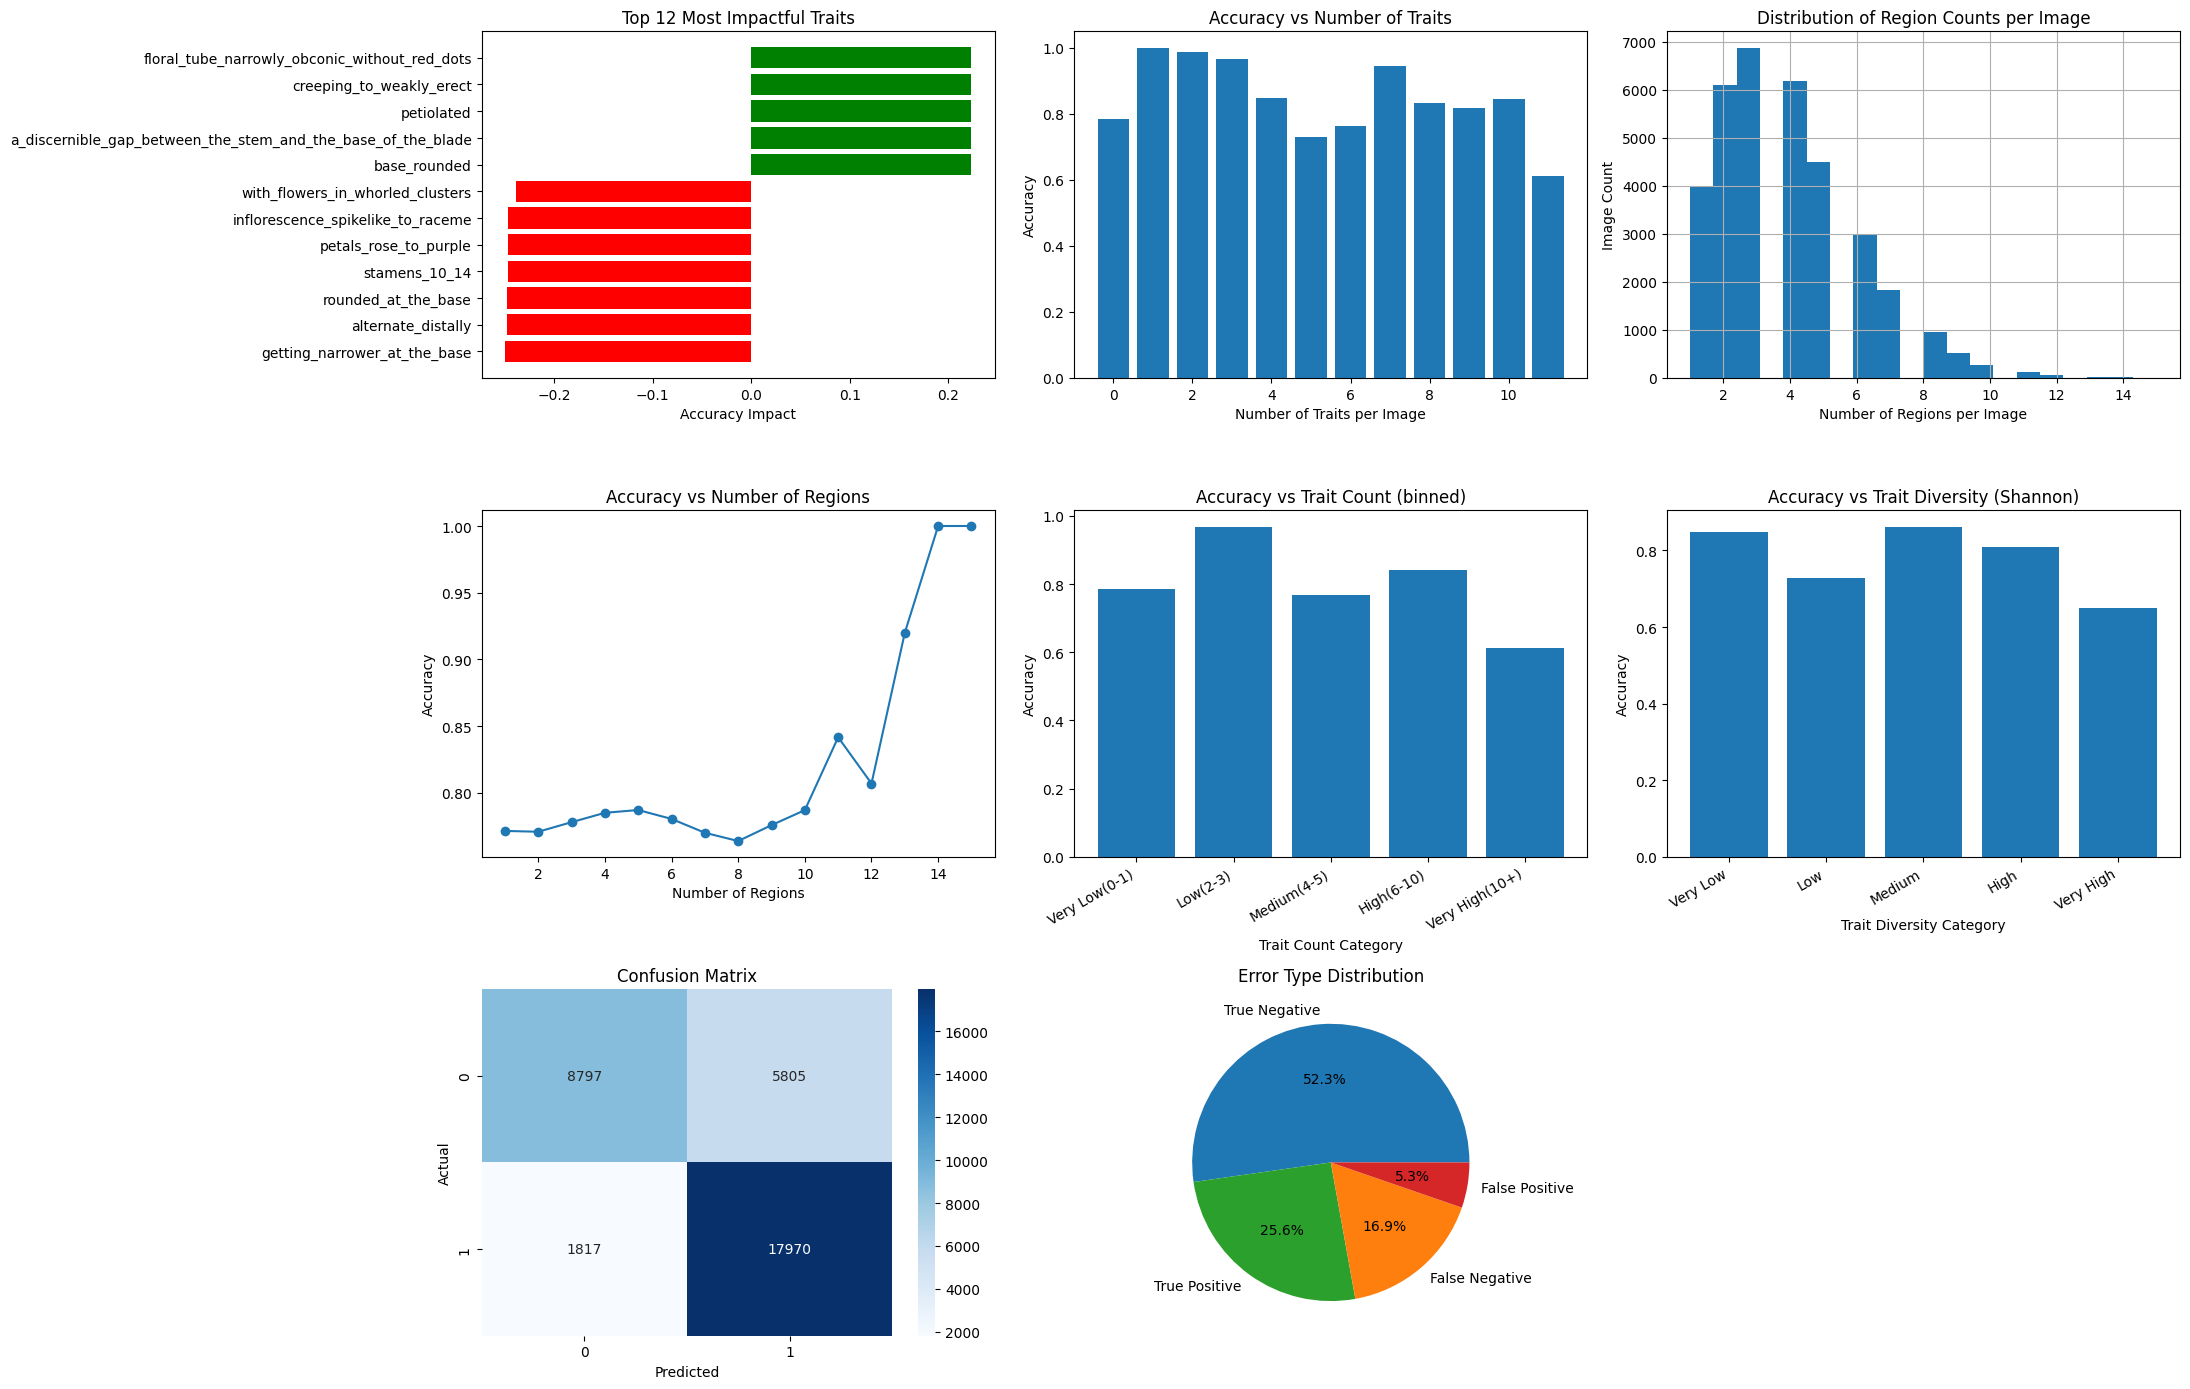

TRAIT CO-OCCURRENCE PATTERNS (Intro)
Plotting co-occurrence for top 16 most frequent traits for readability.


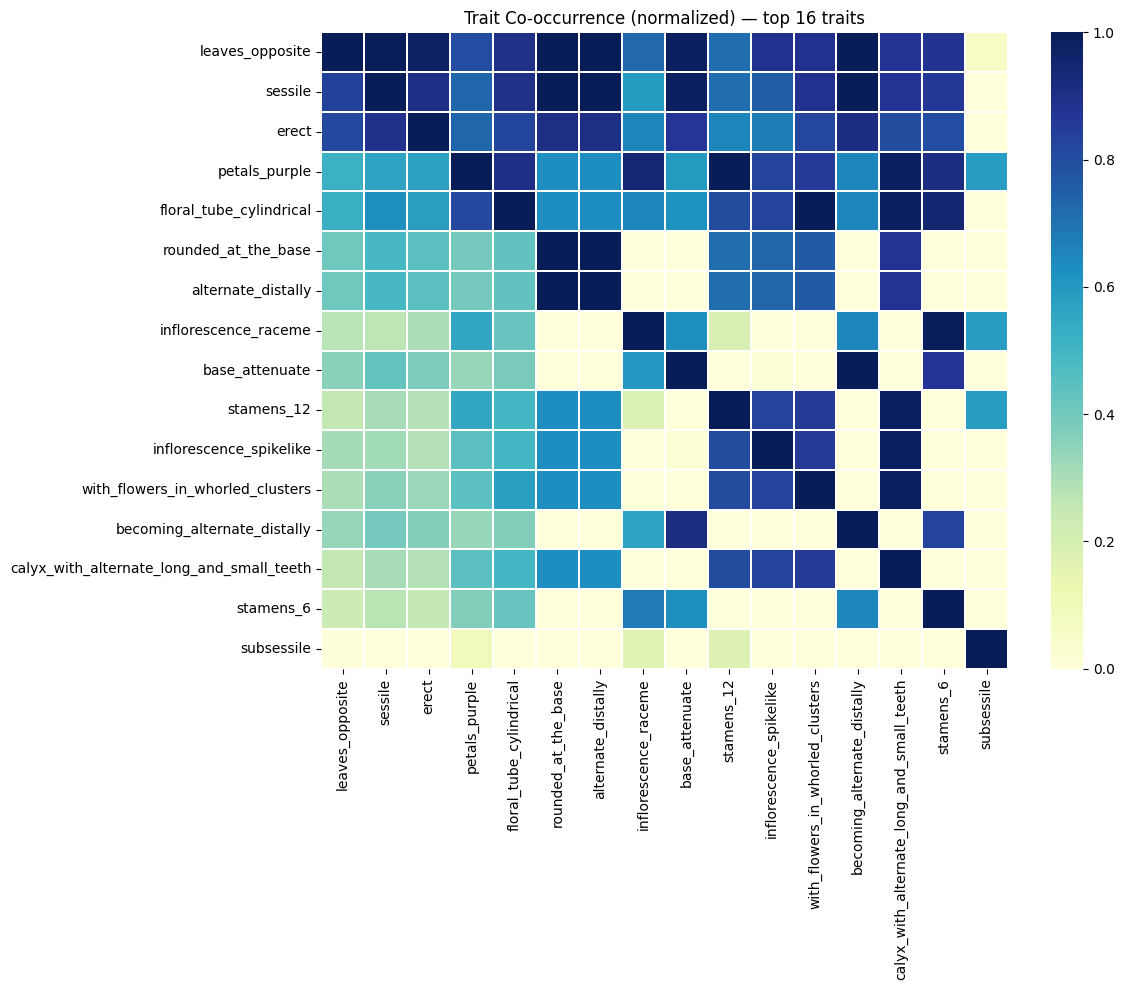


Interpretation:
  - Cells close to 1 mean that nearly all images with trait_i also have trait_j (given denominator used).
  - Use the top-left block to identify trait clusters frequently co-occurring.

TRAIT CO-OCCURRENCE PATTERNS (Intro)
Plotting co-occurrence for top 20 most frequent traits for readability.


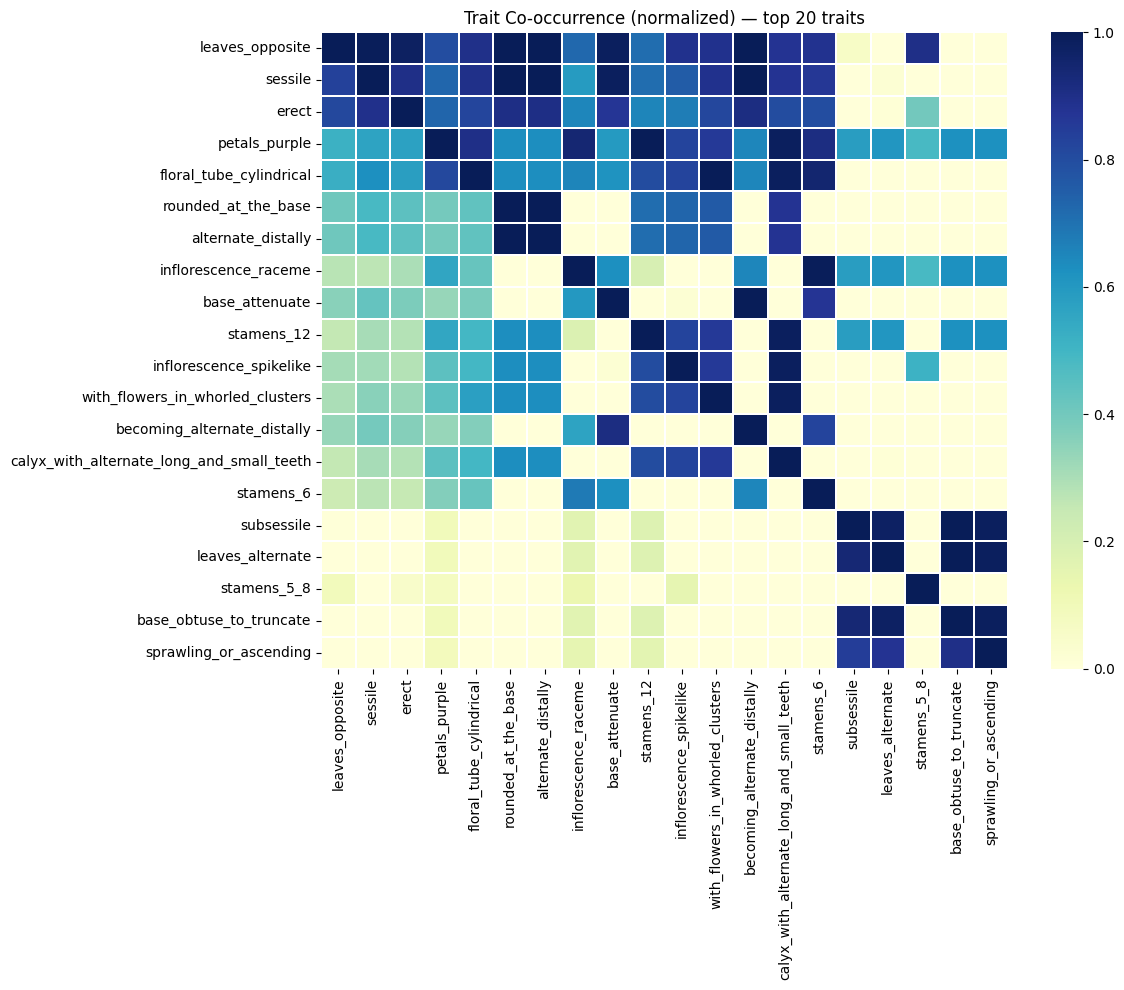


Interpretation:
  - Cells close to 1 mean that nearly all images with trait_i also have trait_j (given denominator used).
  - Use the top-left block to identify trait clusters frequently co-occurring.



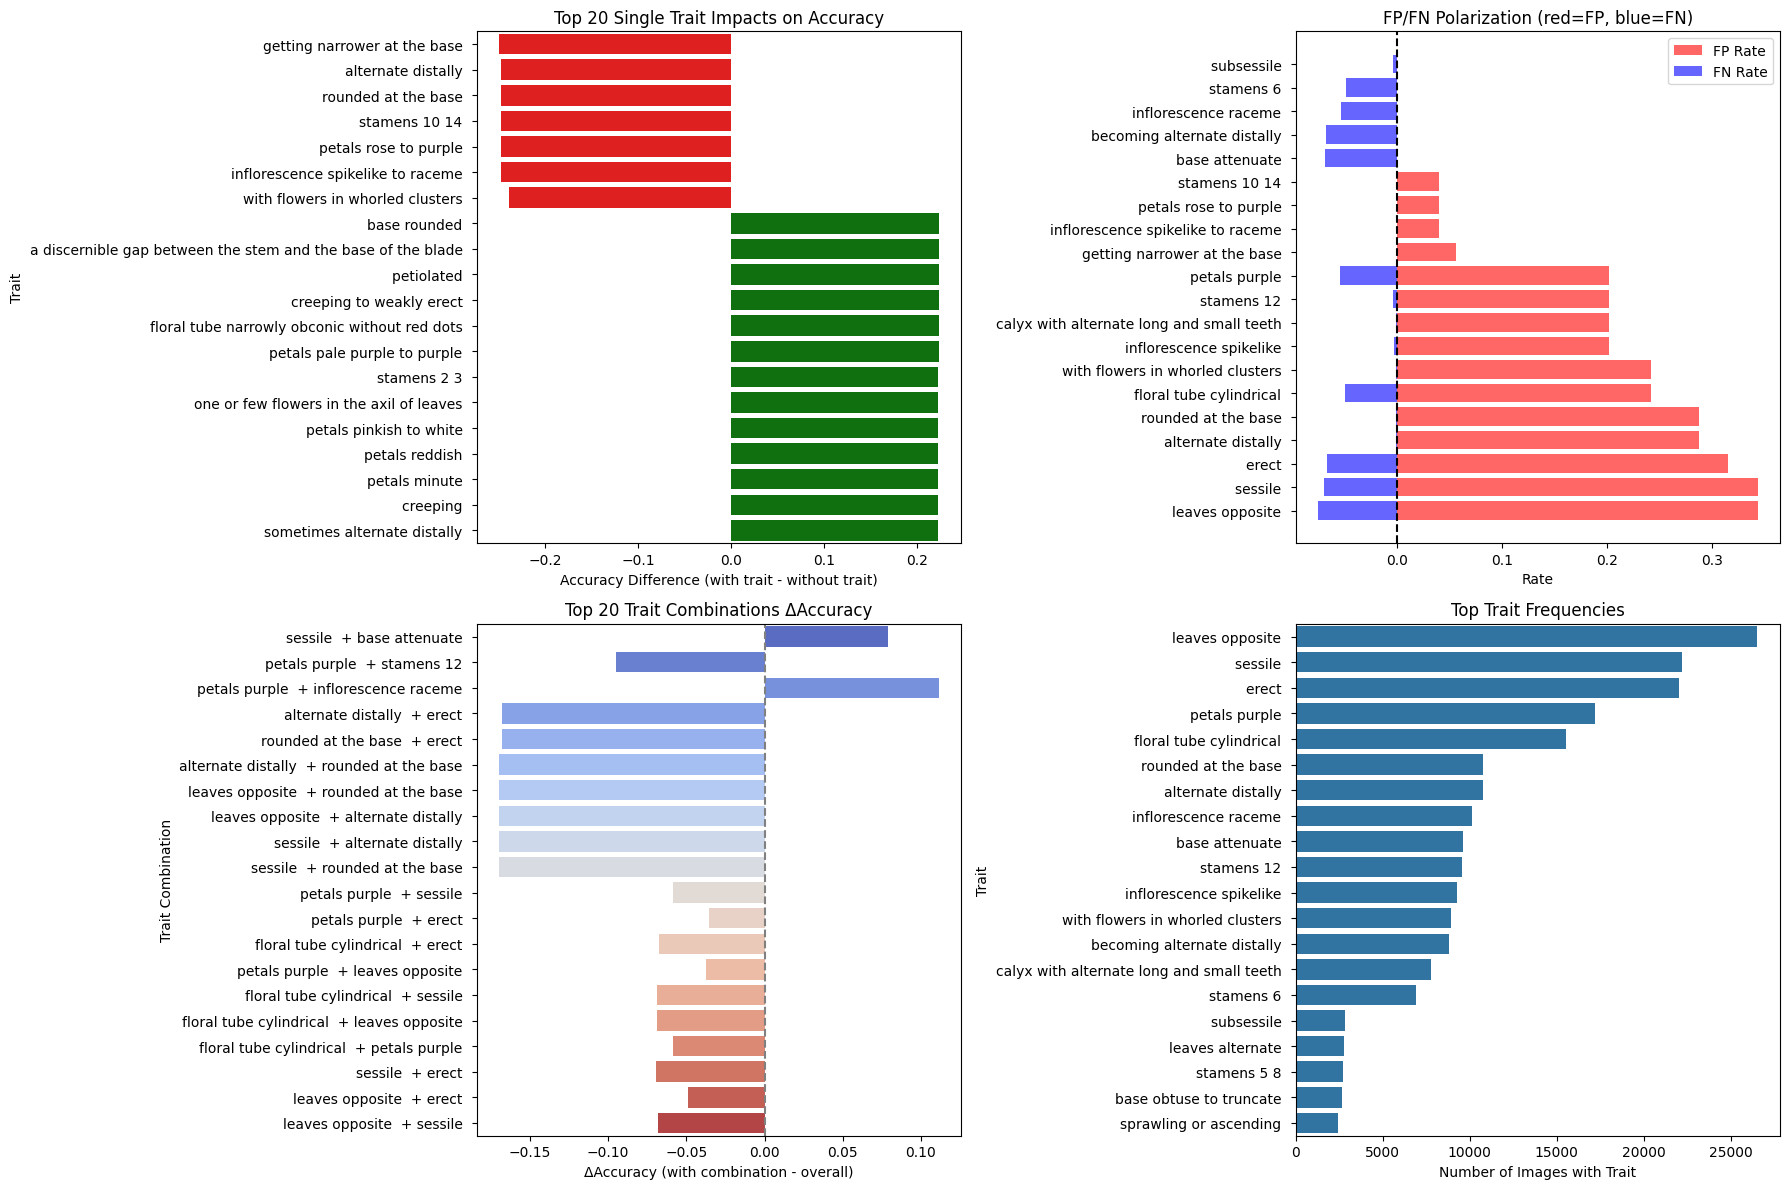


REPORT COMPLETE. Outputs dictionary contains DataFrames and analyses for further programmatic use.


In [44]:
image_analyzer = EnhancedImageLevelAnalyzer(merged_df)

image_results = image_analyzer.comprehensive_summary_report()

for key, value in image_results.items():
    if hasattr(value, 'to_csv'):
        value.to_csv(f'images_results/{key}.csv', index=False)

# Analysis for a botanical review

In [27]:
image_analyzer = EnhancedImageLevelAnalyzer(merged_df)
rules = image_analyzer.trait_rule_analysis_apriori()

Preparing data...

In our analysis:
- True Positive = Invasive plants correctly predicted
- True Negative = Non Invasive plants correctly predicted
- False Positive = Non Invasive plants predicted as Invasive
- False Negative = Invasive plants predicted as Non Invasive

Analyzer ready!

TRAIT RULE ANALYSIS (Apriori)
Mining frequent trait subsets (support ≥ 0.01, confidence ≥ 0.6, max_len=4).

Top rules for True Positive:
                                         antecedents  confidence      lift
0  (trait_erect_present, trait_inflorescence_spik...    0.613348  4.506931
1  (trait_sessile_present, trait_stamens_12_prese...    0.610481  5.062417
2  (trait_stamens_12_present, trait_petals_purple...    0.610481  5.062417
3  (trait_inflorescence_spikelike_present, trait_...    0.610481  5.062417
4  (trait_floral_tube_cylindrical_present, trait_...    0.610481  5.062417
Interpretation: Traits ['trait_erect_present', 'trait_inflorescence_spikelike_present'] strongly predict True Positive.

Top 

In [33]:
rules["True Negative"] = rules["True Negative"].groupby('antecedents', as_index=False).agg({
                'confidence':'max',
                'lift':'max',
                'support':'max'
            })

rules["True Negative"]

,antecedents,confidence,lift,support
0,(trait_sessile_base_narrowly_attenuate_present),0.982456,17.237594,0.056995
1,"(trait_solitary_in_leaf_axils_present, trait_l...",0.971869,20.478918,0.042194
2,"(trait_floral_tube_obconic_present, trait_leav...",0.971869,20.478918,0.042194
3,"(trait_erect_present, trait_stamens_5_8_present)",0.965233,28.084193,0.030678
4,"(trait_inflorescence_raceme_present, trait_ere...",0.965233,28.084193,0.030678
...,...,...,...,...
1728,"(trait_subsessile_present, trait_floral_tube_o...",0.972007,12.455634,0.047457
1729,"(trait_subsessile_present, trait_red_dotted_pr...",0.971869,20.478918,0.042194
1730,"(trait_subsessile_present, trait_floral_tube_o...",0.971869,3.690139,0.042194
1731,"(trait_subsessile_present, trait_floral_tube_o...",0.971869,1.859855,0.042194


In [34]:
for key, value in rules.items():
    value = value.groupby('antecedents', as_index=False).agg({
                'confidence':'max',
                'lift':'max',
                'support':'max'
            })
    if hasattr(value, 'to_csv'):
        value.to_csv(f'images_results/rules/{key}.csv', index=False)

In [43]:
import re

def parse_frozenset_to_list(cell, prefix="trait_", suffix_to_strip="_present"):
    """
    Parse strings like "frozenset({'trait_a','trait_b'})" into ['a','b'].
    Returns empty list for NaNs, frozenset() empty, or unparsable values.
    """
    if pd.isna(cell):
        return []
    s = str(cell).strip()
    # Handle an empty frozenset representation
    if s == "frozenset()" or s.lower() == "frozenset({})":
        return []
    # Find the { ... } content
    m = re.search(r"\{(.*)\}", s)
    if not m:
        return []
    inner = m.group(1).strip()
    if inner == "":
        return []
    # Split by comma (items don't contain commas in your data)
    parts = [p.strip() for p in inner.split(",") if p.strip() != ""]
    cleaned = []
    for p in parts:
        # Remove surrounding quotes if present
        if (p.startswith("'") and p.endswith("'")) or (p.startswith('"') and p.endswith('"')):
            p = p[1:-1]
        # Remove the prefix 'trait_' if present
        if prefix and p.startswith(prefix):
            p = p[len(prefix):]
        # Remove trailing suffix like '_present' (optional)
        if suffix_to_strip and p.endswith(suffix_to_strip):
            p = p[:-len(suffix_to_strip)]
        cleaned.append(p)
    return cleaned
outcomes = ["True Positive", "True Negative"]

for ot in outcomes:
    df = pd.read_csv(f'images_results/rules/{ot}.csv')

    # Apply parser and expand to columns
    df["antecedents_list"] = df["antecedents"].apply(parse_frozenset_to_list)

    # Determine how many columns we want (max 4 as you requested)
    max_items = min(4, df["antecedents_list"].map(len).max())

    # Create antecedent_1 .. antecedent_4 (always create 4 for consistency)
    for i in range(4):
        colname = f"antecedent_{i+1}"
        if i < max_items:
            df[colname] = df["antecedents_list"].apply(lambda lst: lst[i] if len(lst) > i else None)
        else:
            df[colname] = None

    # Optionally drop helper column
    df = df.drop(columns=["antecedents_list"])
    df = df.drop(columns=["antecedents"])
    df.to_csv(f"images_results/rules/{ot}_cleaned.csv", sep=";")

In [26]:
traits

{'lythrum acutangulum': {'leaf': [], 'flower': [], 'stem': []},
 'lythrum alatum': {'leaf': ['leaves opposite',
   'becoming alternate distally',
   'sessile',
   'base attenuate'],
  'flower': ['inflorescence raceme',
   'petals purple',
   'floral tube cylindrical',
   'stamens 6'],
  'stem': ['erect']},
 'lythrum album': {'leaf': ['leaves alternate'],
  'flower': ['petals white'],
  'stem': ['erect']},
 'lythrum americanum': {'leaf': [], 'flower': [], 'stem': []},
 'lythrum anatolicum': {'leaf': ['leaves opposite',
   'sessile',
   'cordate at base'],
  'flower': ['petals purple', 'stamens 12 in 2 whorls'],
  'stem': ['erect']},
 'lythrum baeticum': {'leaf': [], 'flower': [], 'stem': []},
 'lythrum borysthenicum': {'leaf': ['leaves opposite but sometimes alternate',
   'sessile',
   'obovate'],
  'flower': ['petals reddish', 'petals minute', 'stamens 6'],
  'stem': ['erect', 'sometimes creeping']},
 'lythrum bryantii': {'leaf': [], 'flower': [], 'stem': []},
 'lythrum californicum':

In [38]:
def find_locked_trait_groups(trait_dict):
    """
    From your species-trait dictionary, return the sets of traits
    that only appear together (never split).
    """
    all_groups = []
    trait_to_groups = {}

    # Collect all trait groups
    for species, parts in trait_dict.items():
        for struct, traits in parts.items():
            if traits:
                group = frozenset(traits)
                all_groups.append(group)
                for t in group:
                    trait_to_groups.setdefault(t, set()).add(group)

    locked_groups = set()
    for group in all_groups:
        # If all traits in the group ONLY ever appear in this exact group
        if all(len(trait_to_groups[t]) == 1 for t in group):
            locked_groups.add(group)

    return locked_groups


def filter_rules_remove_locked(df_rules, locked_groups):
    """
    Remove rules whose antecedents are entirely within one locked group.
    """
    mask = []
    for _, row in df_rules.iterrows():
        antecedent = frozenset(row['antecedents'])
        drop = any(antecedent == group for group in locked_groups)
        mask.append(not drop)
    return df_rules[mask].reset_index(drop=True)

groups = find_locked_trait_groups(traits)
groups

{frozenset({'petals pinkish to white'}),
 frozenset({'4 minute petals', 'pink'}),
 frozenset({'creeping to weakly erect'}),
 frozenset({'leaves with petiole'}),
 frozenset({'sprawling or ascending'}),
 frozenset({'erect to weakly erect'}),
 frozenset({'often with a darker midrib', 'petals pinkish'}),
 frozenset({'petals white'}),
 frozenset({'needle-like leaves'}),
 frozenset({'creeping'}),
 frozenset({'prostrate to weakly erect'}),
 frozenset({'erect or decumbent'}),
 frozenset({'prostrate'}),
 frozenset({'broader at the base', 'leaves sessile'}),
 frozenset({'prostrate and spreading'})}

In [ ]:
_, fi_per_error = image_analyzer.predictive_feature_analysis()

PREDICTIVE FEATURE IMPORTANCE (Intro)
What you'll see: Random Forest feature importances predicting whether the image-level prediction was correct.

Top global predictive features:
                                            feature  importance
174                                 background_frac    0.128269
173                                       hand_frac    0.106879
171                                 trait_diversity    0.068525
172                                   trait_density    0.067389
95                                 trait_erect_freq    0.056032
94                   trait_rounded_at_the_base_freq    0.042773
170                                       n_regions    0.041954
93                    trait_alternate_distally_freq    0.040905
92                               trait_sessile_freq    0.034092
8                  trait_alternate_distally_present    0.027759
86      trait_with_flowers_in_whorled_clusters_freq    0.027278
9                 trait_rounded_at_the_base_present

In [44]:
for key, value in fi_per_error.items():
    if hasattr(value, 'to_csv'):
        value.to_csv(f'images_results/random_forest/{key}.csv', sep=";", index=False)